# Benchmarking

# TODO: Try 1D GP 

In [1]:
import sys
import time
import torch
import gpytorch
import datasets
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import evaluation_metrics as em
import optuna

from optuna.pruners import MedianPruner
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
from datasets import (
    load_dataset,
    min_max_scale_dataset
)

sys.path.insert(0, '/Users/gizemnurdal/Workspace/swim-meets-kans/pykan')
sys.path.insert(0, '/Users/gizemnurdal/Workspace/swim-meets-kans/sgkan')
from hkan.hkan import (
    Sigmoid, Gaussian, ReLU, Tanh, Softplus, Identity,
    make_hkan_layer, extend_hkan, set_tqdm_disable,
)
from kan import KAN # type: ignore
from sgkan import surrogate_guided_kan as sgkan
from sgkan import gaussian_process_models as gp
from sgkan import gp_swim_like_pairs as gs

torch.set_default_dtype(torch.float64)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")


/Users/gizemnurdal/miniconda3/envs/swim-meets-kans/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


## Utilities Functions

In [2]:
def build_hkan_from_params(model_params, tqdm_disable=False):
    """
    Build an HKAN model from a list of layer-param dicts.

    Args:
        model_params: List of dicts with layer config (layer, n_vars_out, basis_fn, etc.)
        tqdm_disable: Disable progress bars in training

    Returns:
        Constructed HKAN model
    """
    # Ensure layers are processed in order (layer 0 first, then extended sequentially)
    params = sorted(model_params, key=lambda p: int(p["layer"]))
    model = None
    set_tqdm_disable(tqdm_disable)

    for p in params:
        layer_idx = int(p["layer"])
        n_vars_out = p["n_vars_out"]
        basis_fn = p["basis_fn"]
        n_basis = p.get("n_basis", 10)
        centers = p.get("centers", "random")
        reg = p.get("regressor", Ridge())

        if layer_idx == 0:
            # Create first layer with specified parameters
            model = make_hkan_layer(
                layer_idx=layer_idx,
                n_vars_out=n_vars_out,
                basis_fn=basis_fn,
                n_basis=n_basis,
                centers=centers,
                expanding_base_regressor=reg,
            )
        else:
            # Stack additional layers on top of existing model
            if model is None:
                raise ValueError("First layer (layer 0) must be provided before extending.")
            model = extend_hkan(
                model,
                layer_idx=layer_idx,
                n_vars_out=n_vars_out,
                basis_fn=basis_fn,
                n_basis=n_basis,
                centers=centers,
                expanding_base_regressor=reg,
            )
    return model

def fit_hkan(model, X_train, y_train):
    """Train HKAN model on training data and report elapsed time."""
    if model:
        start_time = time.time()
        model.fit(X_train, y_train)
        elapsed_time = time.time() - start_time
        print(f"\n✓ Training completed in {elapsed_time:.4f} seconds")

def predict_hkan(model, X_test):
    """Make predictions with HKAN model and report elapsed time."""
    if model:
        start_time = time.time()
        predictions = model.predict(X_test)
        elapsed_time = time.time() - start_time
        print(f"✓ Prediction completed in {elapsed_time:.4f} seconds")
        return predictions

In [3]:
def build_kan(width, grid=3, k=3, seed=42):
    """
    Build a KAN model with specified architecture.

    Args:
        width: List of layer widths, e.g., [2, 5, 1]
        grid: Grid size for spline basis
        k: Spline degree
        seed: Random seed for reproducibility

    Returns:
        KAN model instance
    """
    return KAN(width=width, grid=grid, k=k, seed=seed, device=device)

def fit_kan(model, X_train, y_train, X_test, y_test, steps=50, opt="Adam", lamb=0.01):
    """
    Train a KAN model with test data for validation.

    Args:
        model: KAN model instance
        X_train, y_train: Training data
        X_test, y_test: Test data for validation
        steps: Number of training iterations
        opt: Optimizer ("LBFGS" or "Adam")
        lamb: Regularization coefficient

    Returns:
        Trained KAN model
    """
    start_time = time.time()
    # Convert numpy arrays to torch tensors on the specified device
    X_train_tensor = torch.tensor(X_train, dtype=torch.float64, device=device)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float64, device=device)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float64, device=device)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float64, device=device)
    
    # Package data into KAN-compatible format
    dataset = {
        'train_input': X_train_tensor, 
        'train_label': y_train_tensor,
        'test_input': X_test_tensor,
        'test_label': y_test_tensor
    }
    model.fit(dataset, opt=opt, steps=steps, lamb=lamb)
    
    elapsed_time = time.time() - start_time
    print(f"\n✓ Training completed in {elapsed_time:.4f} seconds")
    return model

def predict_kan(model, X_test):
    """
    Make predictions with a KAN model.

    Args:
        model: Trained KAN model
        X_test: Input data for prediction

    Returns:
        Predictions as numpy array
    """
    start_time = time.time()
    # Convert to tensor, forward pass, then detach and convert back to numpy
    X_test_tensor = torch.tensor(X_test, dtype=torch.float64, device=device)
    predictions = model(X_test_tensor).detach().cpu().numpy()
    elapsed_time = time.time() - start_time
    print(f"✓ Prediction completed in {elapsed_time:.4f} seconds")
    return predictions

In [4]:
# ─── Kernel utilities ──────────────────────────────────────────
# TODO: sin + sin kernel
def create_rbf_kernel(input_dim):
    """
    Create RBF kernel with ARD (automatic relevance determination).
    
    RBF: Choose it when you are confident the function is globally smooth with no 
    sharp local changes.
    """
    return gpytorch.kernels.ScaleKernel(
        gpytorch.kernels.RBFKernel(ard_num_dims=input_dim)
    )

def create_matern_kernel(input_dim, nu=2.5):
    """
    Create Matérn kernel with ARD (automatic relevance determination).
    
    Matérn ν=2.5: Choose it as the default for most real-world and physical data, 
    where the function is smooth enough to be differentiable but not so smooth that 
    infinitely many derivatives are guaranteed.
    """
    return gpytorch.kernels.ScaleKernel(
        gpytorch.kernels.MaternKernel(nu=nu, ard_num_dims=input_dim)
    )

def fit_sgkan(X_train, y_train, layer_configs, activation=torch.tanh, kernel=None, 
              lr=0.1, num_inducing=500, num_iters=100):
    """
    Train SGKAN (Surrogate-Guided KAN) model with optional custom kernel and GP hyperparameters.
    
    SGKAN uses a Gaussian process surrogate to guide the training of a KAN-like model,
    combining the interpretability of KAN with the uncertainty quantification of GPs.

    Args:
        X_train: Training input data (numpy array)
        y_train: Training target data (numpy array)
        layer_configs: List of dicts with layer configuration (width, M, G, T parameters)
        activation: Activation function (default: torch.tanh)
        kernel: GPyTorch kernel for the Gaussian process (default: RBF with ARD)
        lr: Learning rate for GP training (default: 0.1)
        num_inducing: Number of inducing points for sparse GP (default: 500)
        num_iters: Number of training iterations for GP (default: 100)

    Returns:
        Tuple of (layers, W_out) representing the trained SGKAN model
    """
    start_time = time.time()
    # Convert numpy arrays to torch tensors
    X_train_tensor = torch.tensor(X_train, dtype=torch.float64)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float64)
    
    # Build the SGKAN model with the specified configuration and GP hyperparameters
    layers, W_out = sgkan.build_sgkan(
        X_train_tensor, y_train_tensor, layer_configs, 
        activation=activation, kernel=kernel,
        lr=lr, num_inducing=num_inducing, num_iters=num_iters
    )
    
    elapsed_time = time.time() - start_time
    print(f"\n✓ Training completed in {elapsed_time:.4f} seconds")
    return layers, W_out

def predict_sgkan(layers, W_out, X_test, activation=torch.tanh):
    """
    Make predictions with a trained SGKAN model.

    Args:
        layers: List of SGKAN layers from fit_sgkan
        W_out: Output weights from fit_sgkan
        X_test: Input data for prediction (numpy array)
        activation: Activation function used during training (default: torch.tanh)

    Returns:
        Predictions as numpy array
    """
    start_time = time.time()
    # Convert to tensor and pass through the trained model
    X_test_tensor = torch.tensor(X_test, dtype=torch.float64)
    predictions = sgkan.predict_sgkan(layers, W_out, X_test_tensor, activation=activation).detach().numpy()
    elapsed_time = time.time() - start_time
    print(f"✓ Prediction completed in {elapsed_time:.4f} seconds")
    return predictions

In [5]:
def print_results(results):
    """
    Pretty-print evaluation results in a formatted table.
    
    Args:
        results: Dict with structure {'train': {'mae': float, 'rmse': float},
                                     'test': {'mae': float, 'rmse': float}}
    """
    # Format header row
    print(f"{'Metric':<15} {'Train':<20} {'Test':<20}")
    print("-" * 55)
    
    # Print MAE and RMSE metrics with scientific notation for readability
    for metric in ['mae', 'rmse']:
        train_val = results['train'][metric]
        test_val = results['test'][metric]
        print(f"{metric.upper():<15} {train_val:<20.6e} {test_val:<20.6e}")

def plot_3d_surface(dataset_name, X_test, y_test, y_pred):
    """
    Plot 3D surface comparison of predicted vs actual values.
    
    Creates side-by-side 3D surface plots for visual comparison of model predictions
    against ground truth. Useful for analyzing model behavior over the input space.

    Args:
        dataset_name: Name of the dataset (used in plot titles)
        X_test: Input test data with shape (n_samples, 2) for 2D input space
        y_test: Ground truth output values
        y_pred: Model predictions matching y_test shape
    """

    
    n_samples = len(X_test)
    # Reshape 1D arrays into 2D grids for surface plotting
    grid_size = int(np.sqrt(n_samples))
    
    # Use only the first perfect square number of samples
    n_use = grid_size * grid_size
    X_test = X_test[:n_use]
    y_test = y_test[:n_use]
    y_pred = y_pred[:n_use]
    
    fig = plt.figure(figsize=(14, 6))
    
    # Extract X1 and X2 dimensions and reshape for surface plotting
    X1 = X_test[:, 0].reshape(grid_size, grid_size)
    X2 = X_test[:, 1].reshape(grid_size, grid_size)
    
    # Plot predicted surface (left subplot)
    ax = fig.add_subplot(121, projection="3d")
    ax.plot_surface(X1, X2, y_pred.reshape(grid_size, grid_size), cmap="viridis")
    ax.set_title(f"{dataset_name} - Predicted")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    ax.set_zlabel("Y")
    
    # Plot actual surface (right subplot)
    ax = fig.add_subplot(122, projection="3d")
    ax.plot_surface(X1, X2, y_test.reshape(grid_size, grid_size), cmap="viridis")
    ax.set_title(f"{dataset_name} - Actual")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    ax.set_zlabel("Y")
    
    plt.tight_layout()
    plt.show()

## TF3 RESULTS

### HKAN

In [6]:
# Load TF3 dataset
tf3 = load_dataset("TF3")
tf3_x_train, tf3_x_test, tf3_y_train, tf3_y_test = tf3["train_input"], tf3["test_input"], tf3["train_label"], tf3["test_label"]

In [7]:
print("TF3 X_train shape:", tf3_x_train.shape)
print("TF3 X_test shape:", tf3_x_test.shape)
print("TF3 y_train range:", tf3_y_train.min(), tf3_y_train.max())
print("TF3 y_train mean:", tf3_y_train.mean())

TF3 X_train shape: (5000, 2)
TF3 X_test shape: (10000, 2)
TF3 y_train range: 0.00536838635182604 0.99085992659527
TF3 y_train mean: 0.502179706457441


In [8]:
# TF3 model params
tf3_model_params = [
    {
        "layer": 0,
        "n_vars_out": 924,
        "basis_fn": Tanh(s=50),
        "n_basis": 39,
        "centers": "random",
        "regressor": Ridge(alpha=0.001),
    },
    {
        "layer": 1,
        "n_vars_out": 1,
        "basis_fn": Identity(),
        "n_basis": 10,
        "centers": "random_data_points",
        "regressor": Ridge(),
    }
]
tf3_model = build_hkan_from_params(tf3_model_params)
tf3_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('expanding_layer_0', ...), ('connecting_layer_0', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,n_vars_out,924
,n_basis,39
,centers,'random'
,basis_fn,<hkan.hkan.Ta...t 0x163882410>
,base_regressor,Ridge(alpha=0.001)
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.001
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True


In [9]:
# Fit HKAN
fit_hkan(tf3_model,  tf3_x_train, tf3_y_train)
tf3_results = em.evaluate(
    tf3_model,
    tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test
)

Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00,  2.96it/s]



✓ Training completed in 12.7785 seconds


In [10]:
print_results(tf3_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             3.772777e-06         4.004800e-06        
RMSE            9.379051e-06         6.676696e-06        


✓ Prediction completed in 7.6681 seconds


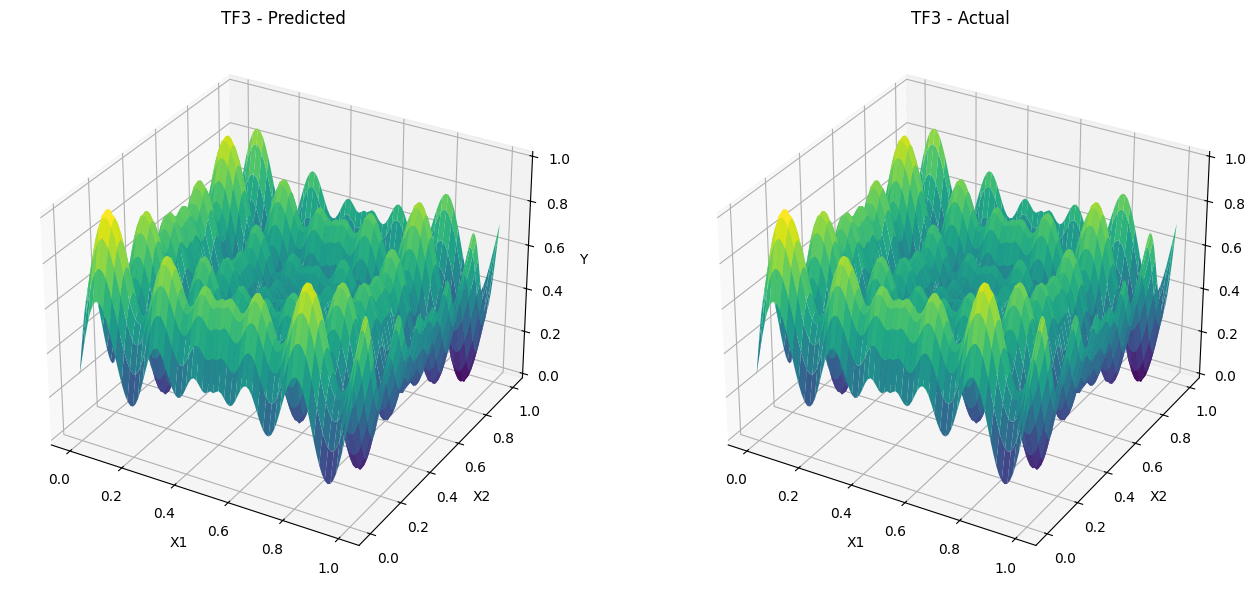

In [11]:
tf3_y_test_pred = predict_hkan(tf3_model, tf3_x_test)
plot_3d_surface("TF3", tf3_x_test, tf3_y_test, tf3_y_test_pred)

### KAN

In [12]:
# Wrapper to add predict method for em.evaluate compatibility
class KANModel:
    def __init__(self, model):
        self.model = model
    def predict(self, X):
        X_tensor = torch.tensor(X, dtype=torch.float64, device=device)
        return self.model(X_tensor).detach().cpu().numpy()

In [13]:
def objective_kan(trial, X_train, y_train, X_test, y_test, n_splits=5):
    """
    Objective function for Optuna to find the best KAN architecture with K-Fold CV.
    
    Uses K-Fold Cross-Validation on training data to evaluate architectures robustly.
    Searches over predefined architecture set W from the HKAN paper.

    Only the network width configuration is searched. All other parameters 
    (grid, spline order k, optimizer, steps) are fixed at KAN defaults.

    The architecture set W is parameterised by n = X_train.shape[1]:
        W = {[n,1], [n,2,1], [n,n+1,1], [n,2n+1,1], [n,2,2,1],
             [n,n+1,2,1], [n,2n+1,2,1], [n,n+1,n+1,1],
             [n,2n+1,n+1,1], [n,2n+1,2n+1,1]}

    Args:
        trial: Optuna trial object
        X_train, y_train: Training data
        X_test, y_test: Test data for final evaluation
        n_splits: Number of folds for cross-validation (default: 5)

    Returns:
        float: Average validation RMSE across all folds (what Optuna minimizes)
    """
    n = X_train.shape[1]

    # Architecture search space W from the HKAN paper
    width_options = [
        [n, 1],
        [n, 2, 1],
        [n, n + 1, 1],
        [n, 2 * n + 1, 1],
        [n, 2, 2, 1],
        [n, n + 1, 2, 1],
        [n, 2 * n + 1, 2, 1],
        [n, n + 1, n + 1, 1],
        [n, 2 * n + 1, n + 1, 1],
        [n, 2 * n + 1, 2 * n + 1, 1],
    ]

    # Suggest architecture
    width_idx = trial.suggest_categorical("width_idx", list(range(len(width_options))))
    width = width_options[width_idx]

    # K-Fold Cross-Validation on training data
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_val_rmses = []
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        # Split into fold train/validation
        X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
        y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
        
        # Build and train model with suggested architecture
        model = build_kan(width=width, grid=3, k=3, seed=42)
        fit_kan(model, X_fold_train, y_fold_train, 
                X_fold_val, y_fold_val,
                steps=100, opt="Adam", lamb=1e-3)
        
        # Evaluate on this fold's validation set
        results = em.evaluate(
            KANModel(model),
            X_fold_train, y_fold_train,
            X_fold_val, y_fold_val
        )
        fold_val_rmses.append(results['test']['rmse'])
    
    # Average validation RMSE across all folds (what Optuna minimizes)
    avg_val_rmse = float(np.mean(fold_val_rmses))
    
    # Also evaluate on the actual test set for reference (only once, not per fold)
    final_model = build_kan(width=width, grid=3, k=3, seed=42)
    fit_kan(final_model, X_train, y_train, X_test, y_test, steps=100, opt="Adam", lamb=1e-3)
    test_results = em.evaluate(KANModel(final_model), X_train, y_train, X_test, y_test)
    test_rmse = float(test_results['test']['rmse'])
    
    # Store test RMSE as user attribute (will appear in trials dataframe)
    trial.set_user_attr("test_rmse", test_rmse)
    trial.set_user_attr("val_rmse", avg_val_rmse)
    
    # Return validation RMSE for optimization
    return avg_val_rmse

# # --- Study setup with K-Fold CV -----------------------------------------------
# print("=" * 70)
# print("Optimizing KAN architecture with 5-Fold Cross-Validation on TF3")
# print("=" * 70)

# study = optuna.create_study(
#     direction='minimize',
#     sampler=optuna.samplers.GridSampler(
#         {"width_idx": list(range(10))}  # Exhaustive over all 10 architectures
#     ),
# )

# n = tf3_x_train .shape[1]
# width_options = [
#     [n, 1], [n, 2, 1], [n, n+1, 1], [n, 2*n+1, 1], [n, 2, 2, 1],
#     [n, n+1, 2, 1], [n, 2*n+1, 2, 1], [n, n+1, n+1, 1],
#     [n, 2*n+1, n+1, 1], [n, 2*n+1, 2*n+1, 1],
# ]

# study.optimize(
#     lambda trial: objective_kan(
#         trial, tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test, n_splits=5
#     ),
#     n_trials=10,
#     show_progress_bar=True,
# )

# # --- Results ---------------------------------------------------------------
# print("\n" + "=" * 70)
# print("Best trial results:")
# print("=" * 70)
# print(f"Best CV Validation RMSE: {study.best_value:.6f}")
# best_test_rmse = study.best_trial.user_attrs.get("test_rmse", "N/A")
# print(f"Best Test RMSE:          {best_test_rmse:.6f}" if isinstance(best_test_rmse, float) else f"Best Test RMSE: {best_test_rmse}")
# print(f"Best width_idx:          {study.best_params['width_idx']}")
# print(f"Best architecture:       {width_options[study.best_params['width_idx']]}")

# # Display all trials with both validation and test RMSE
# trials_df = study.trials_dataframe()
# print(f"\nAll {len(trials_df)} trials:")
# print(trials_df[['number', 'value', 'params_width_idx', 'user_attrs_val_rmse', 'user_attrs_test_rmse']].to_string())


# trials_df = trials_df.rename(columns={
#     "user_attrs_test_rmse": "test_rmse",
#     "user_attrs_val_rmse": "val_rmse",
# })
# trials_df['duration'] = trials_df['duration'].dt.total_seconds()
# trials_df.to_csv("data/tf3_kan_optuna_search.csv")

In [14]:
tf3_kan_optuna_search = pd.read_csv("data/tf3_kan_optuna_search.csv")
tf3_kan_optuna_search.sort_values("val_rmse")

,Unnamed: 0,number,value,datetime_start,datetime_complete,duration,params_width_idx,test_rmse,val_rmse,system_attrs_grid_id,system_attrs_search_space,state
8,8,8,0.162384,2026-06-13 14:26:52.091604,2026-06-13 14:27:42.439852,50.348248,0,0.164722,0.162384,8,"{'width_idx': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}",COMPLETE
5,5,5,0.163563,2026-06-13 14:23:48.570564,2026-06-13 14:24:45.748929,57.178365,6,0.163949,0.163563,5,"{'width_idx': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}",COMPLETE
4,4,4,0.164660,2026-06-13 14:22:58.955535,2026-06-13 14:23:48.569249,49.613714,1,0.487747,0.164660,4,"{'width_idx': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}",COMPLETE
7,7,7,0.170057,2026-06-13 14:25:43.455040,2026-06-13 14:26:52.090105,68.635065,3,0.182046,0.170057,7,"{'width_idx': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}",COMPLETE
1,1,1,0.172992,2026-06-13 14:19:59.110463,2026-06-13 14:21:00.906429,61.795966,8,0.164513,0.172992,1,"{'width_idx': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}",COMPLETE
9,9,9,0.222863,2026-06-13 14:27:42.441347,2026-06-13 14:28:45.641345,63.199998,5,0.196609,0.222863,9,"{'width_idx': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}",COMPLETE
2,2,2,0.286203,2026-06-13 14:21:00.907829,2026-06-13 14:21:56.362376,55.454547,4,0.163476,0.286203,2,"{'width_idx': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}",COMPLETE
0,0,0,0.399037,2026-06-13 14:18:59.897997,2026-06-13 14:19:59.108991,59.210994,2,0.160471,0.399037,0,"{'width_idx': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}",COMPLETE
3,3,3,0.999206,2026-06-13 14:21:56.363869,2026-06-13 14:22:58.954097,62.590228,9,0.163668,0.999206,3,"{'width_idx': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}",COMPLETE
6,6,6,1.370679,2026-06-13 14:24:45.750218,2026-06-13 14:25:43.453366,57.703148,7,0.361969,1.370679,6,"{'width_idx': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}",COMPLETE


In [15]:
# Create TF3 KAN model with architecture [2, 3, 1]
tf3_kan_model = build_kan(width=[2, 1], grid=3, k=3, seed=42)

checkpoint directory created: ./model
saving model version 0.0


In [16]:
# Train TF3 KAN model
fit_kan(tf3_kan_model, tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test, steps=100, opt="Adam", lamb=1e-3)

tf3_kan_results = em.evaluate(
    KANModel(tf3_kan_model),
    tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test
)

| train_loss: 1.61e-01 | test_loss: 1.64e-01 | reg: 2.67e-01 | : 100%|█| 100/100 [00:19<00:00,  5.01


saving model version 0.1

✓ Training completed in 19.9658 seconds


In [17]:
print_results(tf3_kan_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             1.298408e-01         1.316747e-01        
RMSE            1.622684e-01         1.647225e-01        


✓ Prediction completed in 0.0077 seconds


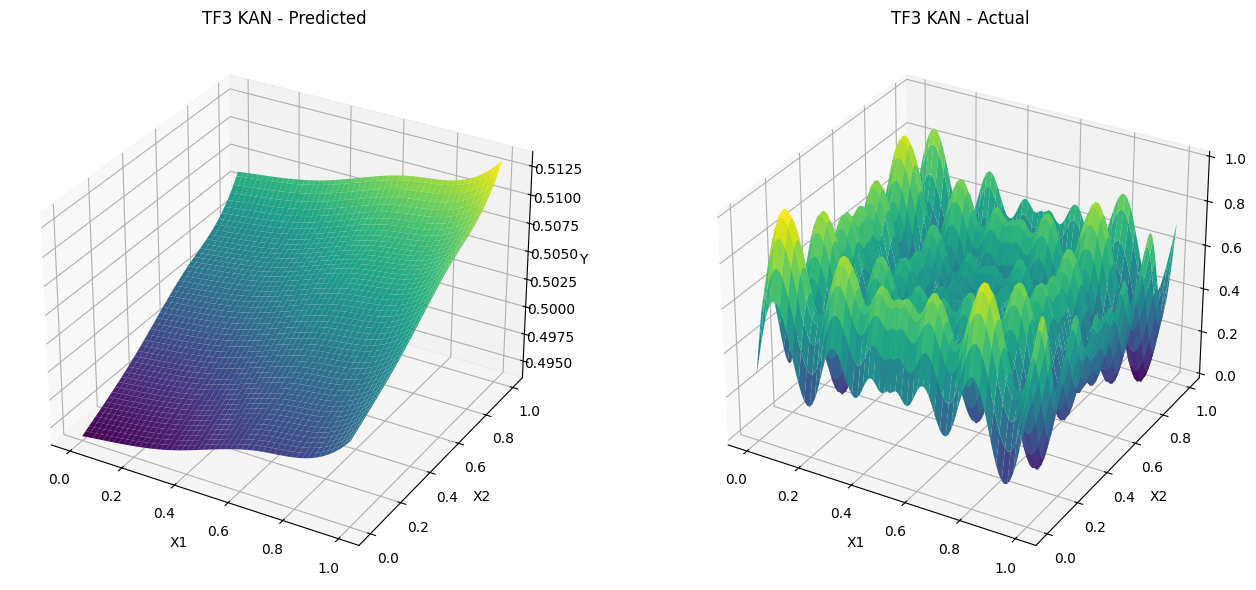

In [18]:
tf3_y_test_pred_kan = predict_kan(tf3_kan_model, tf3_x_test)

plot_3d_surface("TF3 KAN", tf3_x_test, tf3_y_test, tf3_y_test_pred_kan)

### GP (Gaussian Process Baseline)

In [19]:
def objective_gp(trial, X_train, y_train, X_test, y_test, n_splits=5):
    """
    Objective function for Optuna to find the best GP hyperparameters with K-Fold CV.
    
    Uses K-Fold Cross-Validation on training data to evaluate hyperparameter sets.
    Searches over learning rate, kernel type, and number of inducing points.

    Args:
        trial: Optuna trial object
        X_train, y_train: Training data
        X_test, y_test: Test data for final evaluation
        n_splits: Number of folds for cross-validation (default: 5)

    Returns:
        float: Average validation RMSE across all folds (what Optuna minimizes)
    """
    # Suggest hyperparameters
    lr = trial.suggest_float("lr", 1e-4, 1e-1, log=True)  # Learning rate
    kernel_type = trial.suggest_categorical("kernel", ["rbf", "matern"])  # Kernel type
    num_inducing = trial.suggest_int("num_inducing", 100, 500)  # Inducing points

    # Select kernel based on suggestion
    if kernel_type == "rbf":
        kernel = create_rbf_kernel(X_train.shape[1])
    else:  # matern
        kernel = create_matern_kernel(X_train.shape[1])
    
    # K-Fold Cross-Validation on training data
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_val_rmses = []
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        # Split into fold train/validation
        X_fold_train = X_train[train_idx]
        y_fold_train = y_train[train_idx]
        X_fold_val = X_train[val_idx]
        y_fold_val = y_train[val_idx]
        
        # Convert to torch tensors
        X_fold_train_t = torch.tensor(X_fold_train, dtype=torch.float64)
        y_fold_train_t = torch.tensor(y_fold_train, dtype=torch.float64)
        X_fold_val_t = torch.tensor(X_fold_val, dtype=torch.float64)
        y_fold_val_t = torch.tensor(y_fold_val, dtype=torch.float64)
        
        # Initialize GP model with suggested hyperparameters
        gp_model, gp_likelihood = gp.init_gp(X_fold_train_t, y_fold_train_t, kernel=kernel, num_inducing=num_inducing)
        
        # Train GP model
        gp_model, gp_likelihood = gp.train_gp(
            gp_model, gp_likelihood, X_fold_train_t, y_fold_train_t,
            num_iters=500, lr=lr
        )
        
        # Evaluate on this fold's validation set
        pred_mean, _ = gp.predict(gp_model, gp_likelihood, X_fold_val_t)
        rmse = em.compute_rmse(pred_mean, y_fold_val_t).item()
        fold_val_rmses.append(rmse)
    
    # Average validation RMSE across all folds (what Optuna minimizes)
    avg_val_rmse = float(np.mean(fold_val_rmses))
    
    # Also evaluate on the actual test set for reference
    X_train_t = torch.tensor(X_train, dtype=torch.float64)
    y_train_t = torch.tensor(y_train, dtype=torch.float64)
    X_test_t = torch.tensor(X_test, dtype=torch.float64)
    y_test_t = torch.tensor(y_test, dtype=torch.float64)
    
    gp_model_final, gp_likelihood_final = gp.init_gp(X_train_t, y_train_t, kernel=kernel, num_inducing=num_inducing)
    gp_model_final, gp_likelihood_final = gp.train_gp(
        gp_model_final, gp_likelihood_final, X_train_t, y_train_t,
        num_iters=500, lr=lr
    )
    
    pred_test, _ = gp.predict(gp_model_final, gp_likelihood_final, X_test_t)
    test_rmse = em.compute_rmse(pred_test, y_test_t).item()
    
    # Store test RMSE as user attribute
    trial.set_user_attr("test_rmse", test_rmse)
    trial.set_user_attr("val_rmse", avg_val_rmse)
    
    return avg_val_rmse

# # --- Study setup with K-Fold CV -----------------------------------------------
# print("=" * 70)
# print("Optimizing GP hyperparameters with 5-Fold Cross-Validation on tf3")
# print("=" * 70)

# study = optuna.create_study(direction='minimize')

# study.optimize(
#     lambda trial: objective_gp(trial, tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test, n_splits=5),
#     n_trials=10,
#     show_progress_bar=True,
# )

# # --- Results ---------------------------------------------------------------
# print("\n" + "=" * 70)
# print("Best trial results:")
# print("=" * 70)
# print(f"Best CV Validation RMSE: {study.best_value:.6f}")
# best_test_rmse = study.best_trial.user_attrs.get("test_rmse", "N/A")
# print(f"Best Test RMSE:          {best_test_rmse:.6f}" if isinstance(best_test_rmse, float) else f"Best Test RMSE: {best_test_rmse}")
# print(f"Best hyperparameters:")
# print(f"  lr:              {study.best_params['lr']:.6f}")
# print(f"  kernel:          {study.best_params['kernel']}")
# print(f"  num_inducing:    {study.best_params['num_inducing']}")

# # Display all trials
# trials_df = study.trials_dataframe()
# print(f"\nAll {len(trials_df)} trials:")
# print(trials_df[['number', 'value', 'params_lr', 'params_kernel', 'params_num_inducing', 'user_attrs_test_rmse']].to_string())

# trials_df = trials_df.rename(columns={
#     "user_attrs_test_rmse": "test_rmse",
#     "user_attrs_val_rmse": "val_rmse",
# })
# trials_df['duration'] = trials_df['duration'].dt.total_seconds()
# trials_df.to_csv("data/tf3_gp_optuna_search.csv")

In [20]:
tf3_gp_optuna_search = pd.read_csv("data/tf3_gp_optuna_search.csv")
tf3_gp_optuna_search.sort_values("val_rmse")

,Unnamed: 0,number,value,datetime_start,datetime_complete,duration,params_kernel,params_lr,params_num_inducing,test_rmse,val_rmse,state
2,2,2,0.149841,2026-06-13 14:40:40.238907,2026-06-13 14:42:49.808443,129.569536,rbf,0.005705,331,0.153542,0.149841,COMPLETE
6,6,6,0.150380,2026-06-13 14:50:06.098823,2026-06-13 14:50:42.909385,36.810562,rbf,0.008526,105,0.156243,0.150380,COMPLETE
8,8,8,0.151371,2026-06-13 14:54:20.985850,2026-06-13 14:55:11.853868,50.868018,matern,0.026417,115,0.156312,0.151371,COMPLETE
5,5,5,0.151779,2026-06-13 14:45:35.588584,2026-06-13 14:50:06.096837,270.508253,matern,0.034803,453,0.156356,0.151779,COMPLETE
4,4,4,0.152577,2026-06-13 14:44:37.897276,2026-06-13 14:45:35.587022,57.689746,rbf,0.085628,179,0.119670,0.152577,COMPLETE
1,1,1,0.185754,2026-06-13 14:37:12.052047,2026-06-13 14:40:40.236792,208.184745,rbf,0.000424,450,0.196886,0.185754,COMPLETE
0,0,0,0.231238,2026-06-13 14:33:30.722589,2026-06-13 14:37:12.050512,221.327923,matern,0.000232,428,0.232108,0.231238,COMPLETE
9,9,9,0.261500,2026-06-13 14:55:11.855370,2026-06-13 14:58:48.482521,216.627151,rbf,0.000258,479,0.267031,0.261500,COMPLETE
7,7,7,0.337831,2026-06-13 14:50:42.911019,2026-06-13 14:54:20.984189,218.073170,rbf,0.000163,487,0.334621,0.337831,COMPLETE
3,3,3,0.399371,2026-06-13 14:42:49.810117,2026-06-13 14:44:37.895502,108.085385,rbf,0.000106,297,0.410234,0.399371,COMPLETE


Training Gaussian Process baseline on TF3
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([5000, 2]), num_inducing=331

Training GP...
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.005705, loss=ELBO
  Iter 100/500, Loss: 0.778683
  Iter 200/500, Loss: 0.762758
  Iter 300/500, Loss: 0.758164
  Iter 400/500, Loss: 0.756552
  Iter 500/500, Loss: 0.755866
[DEBUG] Training complete.
  Lengthscale: tensor([[0.5812, 1.2607]])
  Outputscale: 0.5117
  Noise: 0.693247
  Mean const: 0.2348
[DEBUG] SparseGPModel and likelihood frozen (eval mode)

Evaluating GP...
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
Metric          Train                Test                
-------------------------------------------------------
MAE             1.201830e-01         1.239454e-01        
RMSE            1.489803e-01         1.536908e-01        
[DEBUG] SparseGPModel and l

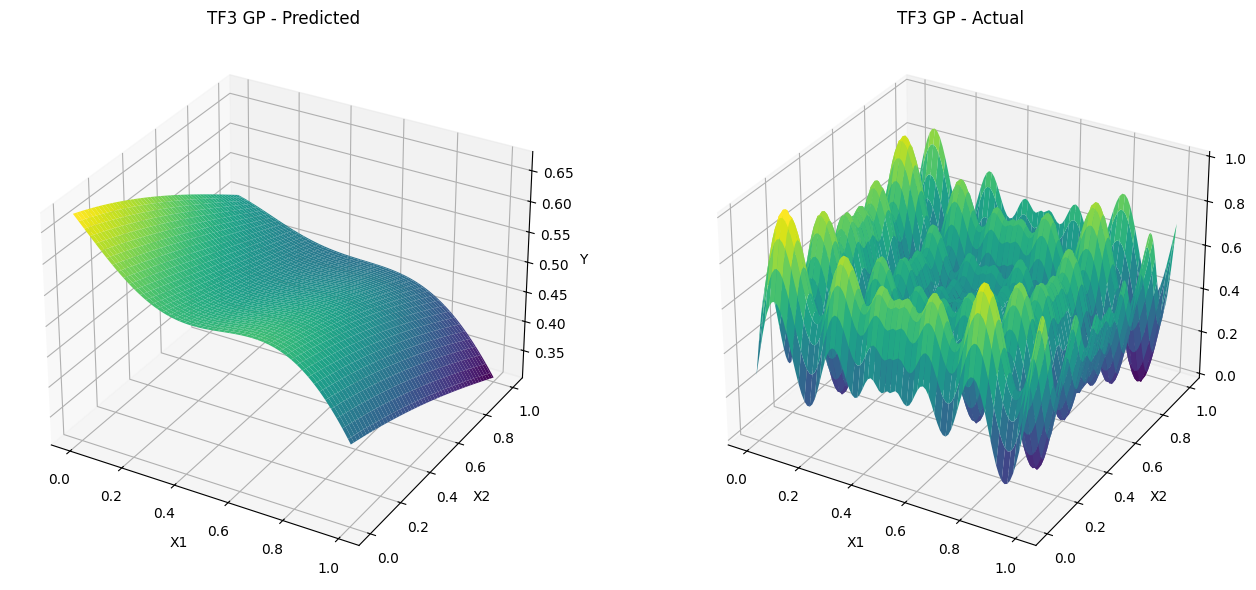

In [21]:
# Wrapper for GP model to add predict method for em.evaluate compatibility
class GPModel:
    """Wrapper for Gaussian Process model for compatibility with em.evaluate()."""
    
    def __init__(self, model, likelihood):
        self.model = model
        self.likelihood = likelihood
    
    def predict(self, X):
        """Make predictions with the GP model."""
        X_tensor = torch.tensor(X, dtype=torch.float64)
        pred_mean, pred_std = gp.predict(self.model, self.likelihood, X_tensor)
        return pred_mean.cpu().numpy()


# TF3 GP Model Training
print("=" * 70)
print("Training Gaussian Process baseline on TF3")
print("=" * 70)

# Convert to torch tensors with float64
X_train_gp = torch.tensor(tf3_x_train, dtype=torch.float64)
y_train_gp = torch.tensor(tf3_y_train, dtype=torch.float64)
X_test_gp = torch.tensor(tf3_x_test, dtype=torch.float64)
y_test_gp = torch.tensor(tf3_y_test, dtype=torch.float64)

# Initialize GP model and likelihood
tf3_gp_model, tf3_gp_likelihood = gp.init_gp(
    X_train_gp,
    y_train_gp,
    kernel=create_rbf_kernel(tf3_x_train.shape[1]),
    num_inducing=331
)

# Train GP model
print("\nTraining GP...")
tf3_gp_model, tf3_gp_likelihood = gp.train_gp(
    tf3_gp_model,
    tf3_gp_likelihood,
    X_train_gp,
    y_train_gp,
    num_iters=500,
    lr=0.005705
)

# Evaluate GP model
print("\nEvaluating GP...")
tf3_gp_results = em.evaluate(
    GPModel(tf3_gp_model, tf3_gp_likelihood),
    tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test
)

print_results(tf3_gp_results)

# Make predictions for visualization
tf3_gp_y_test_pred, _ = gp.predict(tf3_gp_model, tf3_gp_likelihood, X_test_gp)
tf3_gp_y_test_pred = tf3_gp_y_test_pred.cpu().numpy()

plot_3d_surface("TF3 GP", tf3_x_test, tf3_y_test, tf3_gp_y_test_pred)

### SGKAN

### SGKAN (Surrogate-Guided KAN) - Hyperparameter Optimization

In [22]:
def objective_sgkan(trial, X_train, y_train, X_test, y_test, kernel=None, lr=0.001, num_inducing=400, num_iters=500, n_splits=5):
    """
    Objective function for Optuna to find the best SGKAN layer configuration with K-Fold CV.
    
    Uses K-Fold Cross-Validation on training data to evaluate hyperparameter sets.
    Searches over SGKAN layer width, M (pair samples), G (grid), and T (interior points).
    GP hyperparameters are passed as arguments.

    Args:
        trial: Optuna trial object
        X_train, y_train: Training data
        X_test, y_test: Test data for final evaluation
        kernel: GPyTorch kernel for GP (default: Matérn kernel with ARD)
        lr: Learning rate for GP training (default: 0.002930)
        num_inducing: Number of inducing points for sparse GP (default: 388)
        num_iters: Number of training iterations for GP (default: 500)
        n_splits: Number of folds for cross-validation (default: 5)

    Returns:
        float: Average validation RMSE across all folds (what Optuna minimizes)
    """
    # Default kernel if not specified
    if kernel is None:
        kernel = create_matern_kernel(X_train.shape[1])
    
    # Suggest SGKAN hyperparameters
    width = trial.suggest_int("width", 32, 200)  # Layer width. TODO: increase boundary
    M = trial.suggest_int("M", 500, 1000)  # Number of candidate pairs
    G = trial.suggest_int("G", 25, 100)  # Grid size for edge functions
    T = trial.suggest_int("T", 5, 50)  # Interior points between pairs
    
    # Layer configuration with suggested hyperparameters
    layer_config = [{"width": width, "M": M, "G": G, "T": T}]
    
    # K-Fold Cross-Validation on training data
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_val_rmses = []
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        # Split into fold train/validation (ensure numpy arrays)
        X_fold_train = X_train[train_idx]
        y_fold_train = y_train[train_idx]
        X_fold_val = X_train[val_idx]
        y_fold_val = y_train[val_idx]
        
        # Build and train SGKAN with suggested hyperparameters
        sgkan_layers, sgkan_W_out = fit_sgkan(
            X_fold_train, y_fold_train, layer_config,
            activation=torch.tanh,
            kernel=kernel,
            lr=lr, num_inducing=num_inducing, num_iters=num_iters
        )
        
        # Evaluate on this fold's validation set
        sgkan_pred_val = sgkan.predict_sgkan(sgkan_layers, sgkan_W_out, X_fold_val, activation=torch.tanh)
        rmse = em.compute_rmse(
            torch.tensor(sgkan_pred_val.flatten(), dtype=torch.float64),
            torch.tensor(y_fold_val.flatten(), dtype=torch.float64)
        ).item()
        fold_val_rmses.append(rmse)
    
    # Average validation RMSE across all folds (what Optuna minimizes)
    avg_val_rmse = float(np.mean(fold_val_rmses))
    
    sgkan_layers_final, sgkan_W_out_final = fit_sgkan(
        X_train, y_train, layer_config,
        activation=torch.tanh,
        kernel=kernel,
        lr=lr, num_inducing=num_inducing, num_iters=num_iters
    )
    
    sgkan_pred_test = sgkan.predict_sgkan(sgkan_layers_final, sgkan_W_out_final, X_test, activation=torch.tanh)
    test_rmse = em.compute_rmse(
        torch.tensor(sgkan_pred_test.flatten(), dtype=torch.float64),
        torch.tensor(y_test.flatten(), dtype=torch.float64)
    ).item()
    
    # Store test RMSE as user attribute
    trial.set_user_attr("test_rmse", test_rmse)
    trial.set_user_attr("val_rmse", avg_val_rmse)
    
    return avg_val_rmse

# # --- Study setup with K-Fold CV -----------------------------------------------
# print("=" * 70)
# print("Optimizing SGKAN hyperparameters with 5-Fold Cross-Validation on tf3")
# print("=" * 70)

# study = optuna.create_study(direction='minimize')

# study.optimize(
#     lambda trial: objective_sgkan(trial, tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test,
#                                   n_splits=5, num_inducing=331, lr=0.005705, num_iters=500, kernel=create_matern_kernel(tf3_x_train.shape[1])),
#     n_trials=10,
#     show_progress_bar=True,
# )

# # --- Results ---------------------------------------------------------------
# print("\n" + "=" * 70)
# print("Best trial results:")
# print("=" * 70)
# print(f"Best CV Validation RMSE: {study.best_value:.6f}")
# best_test_rmse = study.best_trial.user_attrs.get("test_rmse", "N/A")
# print(f"Best Test RMSE:          {best_test_rmse:.6f}" if isinstance(best_test_rmse, float) else f"Best Test RMSE: {best_test_rmse}")
# print(f"Best hyperparameters:")
# print(f"  width:  {study.best_params['width']}")
# print(f"  M:      {study.best_params['M']}")
# print(f"  G:      {study.best_params['G']}")
# print(f"  T:      {study.best_params['T']}")

# # Display all trials
# trials_df = study.trials_dataframe()
# print(f"\nAll {len(trials_df)} trials:")
# print(trials_df[['number', 'value', 'params_width', 'params_M', 'params_G', 'params_T', 'user_attrs_test_rmse']].to_string())

# trials_df = trials_df.rename(columns={
#     "user_attrs_test_rmse": "test_rmse",
#     "user_attrs_val_rmse": "val_rmse",
# })
# trials_df['duration'] = trials_df['duration'].dt.total_seconds()
# trials_df.to_csv("data/tf3_sgkan_optuna_search.csv")

In [23]:
tf3_sgkan_optuna_search = pd.read_csv("data/tf3_sgkan_optuna_search.csv")
tf3_sgkan_optuna_search.sort_values("val_rmse")

,Unnamed: 0,number,value,datetime_start,datetime_complete,duration,params_G,params_M,params_T,params_width,test_rmse,val_rmse,state
6,6,6,0.080460,2026-06-13 15:27:33.551694,2026-06-13 15:30:51.262169,197.710475,47,918,43,190,0.061668,0.080460,COMPLETE
3,3,3,0.088202,2026-06-13 15:18:17.163244,2026-06-13 15:21:15.618338,178.455094,65,733,43,139,0.106240,0.088202,COMPLETE
1,1,1,0.092630,2026-06-13 15:11:46.032064,2026-06-13 15:14:59.932816,193.900752,64,529,43,145,0.085479,0.092630,COMPLETE
4,4,4,0.093038,2026-06-13 15:21:15.619850,2026-06-13 15:24:25.846016,190.226166,67,822,25,125,0.102463,0.093038,COMPLETE
0,0,0,0.094500,2026-06-13 15:08:44.605297,2026-06-13 15:11:46.030429,181.425132,54,544,31,131,0.081152,0.094500,COMPLETE
9,9,9,0.098476,2026-06-13 15:37:13.972610,2026-06-13 15:40:24.146256,190.173646,25,599,42,114,0.094210,0.098476,COMPLETE
8,8,8,0.109960,2026-06-13 15:34:03.326047,2026-06-13 15:37:13.970865,190.644818,34,724,36,84,0.122706,0.109960,COMPLETE
7,7,7,0.115421,2026-06-13 15:30:51.263919,2026-06-13 15:34:03.324219,192.060300,80,513,47,81,0.129249,0.115421,COMPLETE
2,2,2,0.127235,2026-06-13 15:14:59.934862,2026-06-13 15:18:17.161366,197.226504,99,764,39,51,0.120642,0.127235,COMPLETE
5,5,5,0.129031,2026-06-13 15:24:25.847623,2026-06-13 15:27:33.549228,187.701605,60,917,40,60,0.132294,0.129031,COMPLETE


In [24]:
# TF3 SGKAN layer configuration
# Single layer with width=5 to match KAN architecture

# Best hyperparameters:
#   width:  190
#   M:      918
#   G:      47
#   T:      43

tf3_sgkan_layer_configs = [
    {"width": 190, "M": 918, "G": 47, "T": 43}
]

# Kernel options (available for use with gp.init_gp):
# - Default (RBF with ARD): passed implicitly
# - Custom Matern: kernel = create_matern_kernel(tf3_x_train.shape[1])
# - Custom RBF: kernel = create_rbf_kernel(tf3_x_train.shape[1])

# Train TF3 SGKAN (currently uses default RBF kernel)
# To use custom kernel, modify sgkan.build_sgkan to accept kernel parameter
tf3_sgkan_layers, tf3_sgkan_W_out = fit_sgkan(
    tf3_x_train, tf3_y_train, 
    tf3_sgkan_layer_configs,
    num_inducing=331,
    num_iters=500,
    lr=0.005705,
    activation=torch.tanh,
    kernel=create_matern_kernel(tf3_x_train.shape[1])
)


─── Layer 1 | input: torch.Size([5000, 2]) ───
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([5000, 2]), num_inducing=331
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.005705, loss=ELBO
  Iter 100/500, Loss: 0.775017
  Iter 200/500, Loss: 0.762528
  Iter 300/500, Loss: 0.759333
  Iter 400/500, Loss: 0.758005
  Iter 500/500, Loss: 0.757271
[DEBUG] Training complete.
  Lengthscale: tensor([[0.6902, 0.7460]])
  Outputscale: 0.5329
  Noise: 0.693247
  Mean const: 0.2500
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] Scores: min=0.0023, max=0.4426, mean=0.1928
[DEBUG] Probs:  min=0.000013,  max=0.002501,  sum=1.000000
[DEBUG] Selected 190 pairs from 918 candidates
[DEBUG] Unique pairs selected: 169 / 190
[DEBUG] x_segments shape:     torch.Size([190, 47, 2])
[DEBUG] edge_functions shape: torch.Size([190, 47])
[DEBUG] Value range: [0.3367, 0.6580]
[DEBUG] H shape: torch.Size([5000, 190])
[DEBUG] H va

In [25]:
# Wrapper for SGKAN model to add predict method for em.evaluate compatibility
class SGKANModel:
    def __init__(self, layers, W_out, activation=torch.tanh):
        self.layers = layers
        self.W_out = W_out
        self.activation = activation
    
    def predict(self, X):
        X_tensor = torch.tensor(X, dtype=torch.float64)
        return sgkan.predict_sgkan(self.layers, self.W_out, X_tensor, activation=self.activation).detach().numpy()

tf3_sgkan_results = em.evaluate(
    SGKANModel(tf3_sgkan_layers, tf3_sgkan_W_out, activation=torch.tanh),
    tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test
)

[DEBUG] H shape: torch.Size([5000, 190])
[DEBUG] H value range: [0.3367, 0.6580]
[DEBUG] H rank (approx): 169
[DEBUG] H shape: torch.Size([10000, 190])
[DEBUG] H value range: [0.3367, 0.6580]
[DEBUG] H rank (approx): 169


In [26]:
print_results(tf3_sgkan_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             5.742779e-02         5.994118e-02        
RMSE            7.125470e-02         7.479679e-02        


[DEBUG] H shape: torch.Size([10000, 190])
[DEBUG] H value range: [0.3367, 0.6580]
[DEBUG] H rank (approx): 169
✓ Prediction completed in 0.0652 seconds


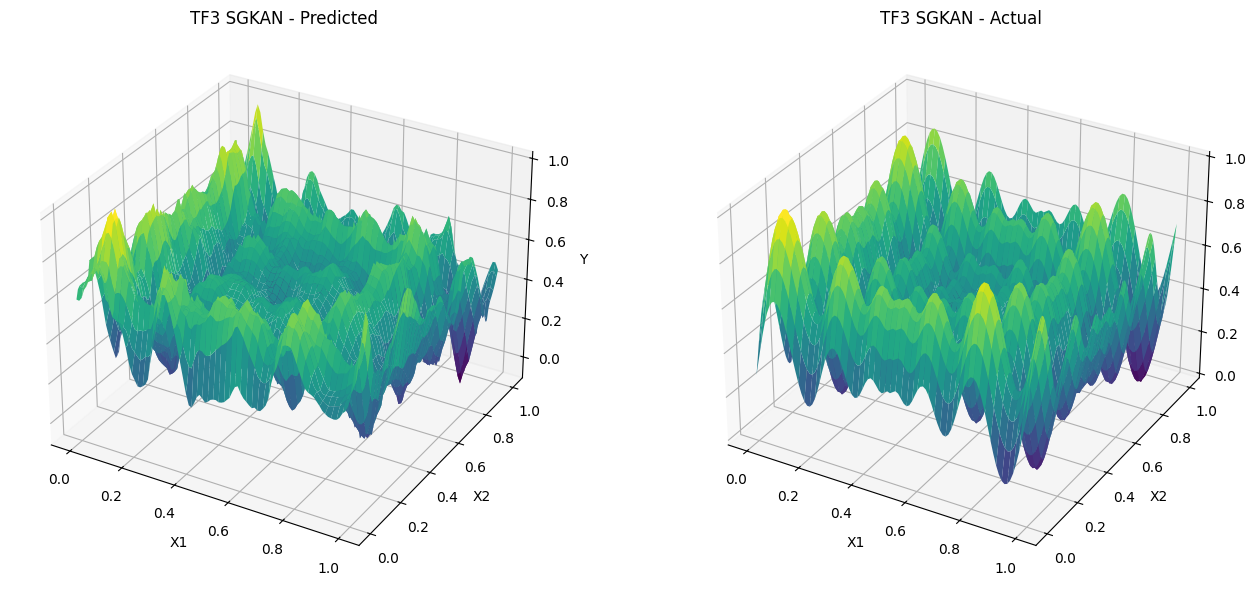

In [27]:
tf3_sgkan_y_test_pred = predict_sgkan(tf3_sgkan_layers, tf3_sgkan_W_out, tf3_x_test, activation=torch.tanh)

plot_3d_surface("TF3 SGKAN", tf3_x_test, tf3_y_test, tf3_sgkan_y_test_pred)

## TF4 RESULTS

### HKAN

In [28]:
# Load TF4 dataset
tf4 = load_dataset("TF4")
tf4_x_train, tf4_x_test, tf4_y_train, tf4_y_test = tf4["train_input"], tf4["test_input"], tf4["train_label"], tf4["test_label"]

In [29]:
print("TF4 X_train shape:", tf4_x_train.shape)
print("TF4 X_test shape:", tf4_x_test.shape)
print("TF4 y_train range:", tf4_y_train.min(), tf4_y_train.max())
print("TF4 y_train mean:", tf4_y_train.mean())

TF4 X_train shape: (3750, 10)
TF4 X_test shape: (1250, 10)
TF4 y_train range: 0.0698151341809996 0.999972806182978
TF4 y_train mean: 0.5528949587494959


In [30]:
# TF4 model params
tf4_model_params = [
    {
        "layer": 0,
        "n_vars_out": 1,
        "basis_fn": Tanh(s=3),
        "n_basis": 2,
        "centers": "equally_spaced",
        "regressor": Ridge(alpha=0.001),
    }
]
tf4_model = build_hkan_from_params(tf4_model_params)
tf4_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('expanding_layer_0', ...), ('connecting_layer_0', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,n_vars_out,1
,n_basis,2
,centers,'equally_spaced'
,basis_fn,<hkan.hkan.Ta...t 0x323a43150>
,base_regressor,Ridge(alpha=0.001)
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.001
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True


In [31]:
# Fit HKAN
fit_hkan(tf4_model,  tf4_x_train, tf4_y_train)
tf4_results = em.evaluate(
    tf4_model,
    tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test
)

Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00, 471.43it/s]


✓ Training completed in 0.0198 seconds


In [32]:
print_results(tf4_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             2.338550e-01         2.323804e-01        
RMSE            2.594233e-01         2.584713e-01        


✓ Prediction completed in 0.0077 seconds


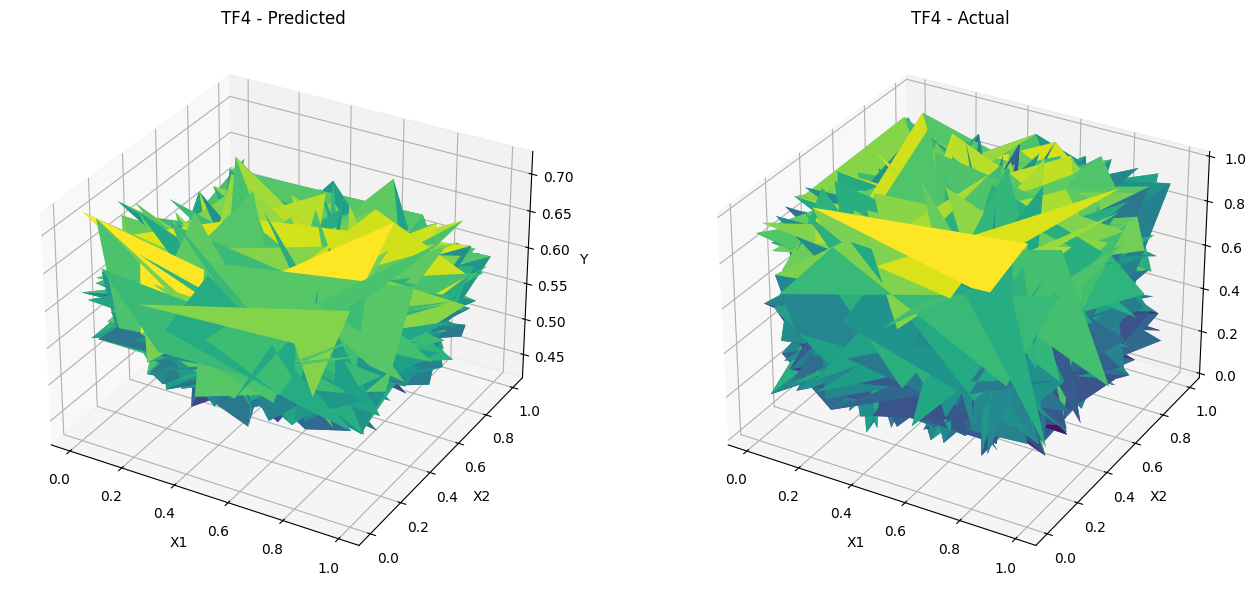

In [33]:
tf4_y_test_pred = predict_hkan(tf4_model, tf4_x_test)
plot_3d_surface("TF4", tf4_x_test[:, :2], tf4_y_test, tf4_y_test_pred)

### KAN

In [34]:
# --- Study setup with K-Fold CV -----------------------------------------------
print("=" * 70)
print("Optimizing KAN architecture with 5-Fold Cross-Validation on TF4")
print("=" * 70)

study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.GridSampler(
        {"width_idx": list(range(10))}  # Exhaustive over all 10 architectures
    ),
)

n = tf4_x_train.shape[1]
width_options = [
    [n, 1], [n, 2, 1], [n, n+1, 1], [n, 2*n+1, 1], [n, 2, 2, 1],
    [n, n+1, 2, 1], [n, 2*n+1, 2, 1], [n, n+1, n+1, 1],
    [n, 2*n+1, n+1, 1], [n, 2*n+1, 2*n+1, 1],
]

study.optimize(
    lambda trial: objective_kan(
        trial, tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test, n_splits=5
    ),
    n_trials=10,
    show_progress_bar=True,
)

# --- Results ---------------------------------------------------------------
print("\n" + "=" * 70)
print("Best trial results:")
print("=" * 70)
print(f"Best CV Validation RMSE: {study.best_value:.6f}")
best_test_rmse = study.best_trial.user_attrs.get("test_rmse", "N/A")
print(f"Best Test RMSE:          {best_test_rmse:.6f}" if isinstance(best_test_rmse, float) else f"Best Test RMSE: {best_test_rmse}")
print(f"Best width_idx:          {study.best_params['width_idx']}")
print(f"Best architecture:       {width_options[study.best_params['width_idx']]}")

# Display all trials with both validation and test RMSE
trials_df = study.trials_dataframe()
print(f"\nAll {len(trials_df)} trials:")
print(trials_df[['number', 'value', 'params_width_idx', 'user_attrs_val_rmse', 'user_attrs_test_rmse']].to_string())

trials_df = trials_df.rename(columns={
    "user_attrs_test_rmse": "test_rmse",
    "user_attrs_val_rmse": "val_rmse",
})
trials_df['duration'] = trials_df['duration'].dt.total_seconds()
trials_df.to_csv("data/tf4_kan_optuna_search.csv")

[I 2026-06-13 17:16:34,755] A new study created in memory with name: no-name-83c4cffc-9c8e-42f4-99b6-b96d1dacaee7


Optimizing KAN architecture with 5-Fold Cross-Validation on TF4


  0%|          | 0/10 [00:00<?, ?it/s]

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.70e-01 | test_loss: 2.71e-01 | reg: 2.38e+02 | : 100%|█| 100/100 [00:07<00:00, 13.21


saving model version 0.1

✓ Training completed in 7.5773 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.65e-01 | test_loss: 2.66e-01 | reg: 1.31e+02 | : 100%|█| 100/100 [00:06<00:00, 14.67


saving model version 0.1

✓ Training completed in 6.8227 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.73e-01 | test_loss: 2.77e-01 | reg: 1.97e+02 | : 100%|█| 100/100 [00:06<00:00, 15.78


saving model version 0.1

✓ Training completed in 6.3436 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.66e-01 | test_loss: 2.61e-01 | reg: 2.46e+02 | : 100%|█| 100/100 [00:06<00:00, 15.27


saving model version 0.1

✓ Training completed in 6.5569 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.67e-01 | test_loss: 2.63e-01 | reg: 2.46e+02 | : 100%|█| 100/100 [00:07<00:00, 13.97


saving model version 0.1

✓ Training completed in 7.1638 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.65e-01 | test_loss: 2.64e-01 | reg: 1.40e+02 | : 100%|█| 100/100 [00:09<00:00, 10.01
Best trial: 0. Best value: 0.267264:  10%|█         | 1/10 [00:44<06:42, 44.71s/it]

saving model version 0.1

✓ Training completed in 9.9999 seconds
[I 2026-06-13 17:17:19,465] Trial 0 finished with value: 0.26726431734737083 and parameters: {'width_idx': 2}. Best is trial 0 with value: 0.26726431734737083.
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 4.35e-01 | test_loss: 4.18e-01 | reg: 2.04e+03 | : 100%|█| 100/100 [00:12<00:00,  7.92


saving model version 0.1

✓ Training completed in 12.6476 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 3.95e+00 | test_loss: 2.81e+00 | reg: 2.39e+03 | : 100%|█| 100/100 [00:12<00:00,  7.90


saving model version 0.1

✓ Training completed in 12.6789 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 6.90e-01 | test_loss: 6.99e-01 | reg: 1.65e+03 | : 100%|█| 100/100 [00:12<00:00,  7.77


saving model version 0.1

✓ Training completed in 12.8815 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 3.91e+00 | test_loss: 4.61e+00 | reg: 4.69e+03 | : 100%|█| 100/100 [00:12<00:00,  7.80


saving model version 0.1

✓ Training completed in 12.8301 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 9.58e-01 | test_loss: 1.21e+00 | reg: 1.79e+03 | : 100%|█| 100/100 [00:12<00:00,  7.84


saving model version 0.1

✓ Training completed in 12.7723 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 6.39e-01 | test_loss: 5.77e-01 | reg: 2.47e+03 | : 100%|█| 100/100 [00:17<00:00,  5.64
Best trial: 0. Best value: 0.267264:  20%|██        | 2/10 [02:06<08:54, 66.77s/it]

saving model version 0.1

✓ Training completed in 17.7476 seconds
[I 2026-06-13 17:18:41,673] Trial 1 finished with value: 1.9414379794452128 and parameters: {'width_idx': 8}. Best is trial 0 with value: 0.26726431734737083.
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.63e-01 | test_loss: 2.65e-01 | reg: 2.76e+01 | : 100%|█| 100/100 [00:06<00:00, 15.58


saving model version 0.1

✓ Training completed in 6.4216 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.63e-01 | test_loss: 2.65e-01 | reg: 2.14e+01 | : 100%|█| 100/100 [00:06<00:00, 15.98


saving model version 0.1

✓ Training completed in 6.2613 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.63e-01 | test_loss: 2.67e-01 | reg: 2.93e+01 | : 100%|█| 100/100 [00:05<00:00, 16.79


saving model version 0.1

✓ Training completed in 5.9608 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.65e-01 | test_loss: 2.59e-01 | reg: 4.37e+01 | : 100%|█| 100/100 [00:05<00:00, 17.10


saving model version 0.1

✓ Training completed in 5.8556 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.67e-01 | test_loss: 2.64e-01 | reg: 3.27e+01 | : 100%|█| 100/100 [00:05<00:00, 16.92


saving model version 0.1

✓ Training completed in 5.9131 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.64e-01 | test_loss: 2.63e-01 | reg: 3.09e+01 | : 100%|█| 100/100 [00:07<00:00, 12.53
Best trial: 2. Best value: 0.264042:  30%|███       | 3/10 [02:45<06:17, 53.88s/it]

saving model version 0.1

✓ Training completed in 7.9824 seconds
[I 2026-06-13 17:19:20,208] Trial 2 finished with value: 0.26404232767900726 and parameters: {'width_idx': 4}. Best is trial 2 with value: 0.26404232767900726.
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.17e+00 | test_loss: 1.28e+00 | reg: 2.19e+03 | : 100%|█| 100/100 [00:16<00:00,  6.07


saving model version 0.1

✓ Training completed in 16.4855 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 8.11e-01 | test_loss: 8.08e-01 | reg: 1.91e+03 | : 100%|█| 100/100 [00:18<00:00,  5.50


saving model version 0.1

✓ Training completed in 18.2127 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 3.09e+00 | test_loss: 3.51e+00 | reg: 4.04e+03 | : 100%|█| 100/100 [00:18<00:00,  5.27


saving model version 0.1

✓ Training completed in 19.0055 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 5.21e+00 | test_loss: 5.11e+00 | reg: 6.72e+03 | : 100%|█| 100/100 [00:19<00:00,  5.16


saving model version 0.1

✓ Training completed in 19.4094 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.06e+00 | test_loss: 2.83e+00 | reg: 5.09e+03 | : 100%|█| 100/100 [00:17<00:00,  5.59


saving model version 0.1

✓ Training completed in 17.9235 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 6.58e-01 | test_loss: 8.69e-01 | reg: 2.17e+03 | : 100%|█| 100/100 [00:24<00:00,  4.03
Best trial: 2. Best value: 0.264042:  40%|████      | 4/10 [04:42<07:52, 78.74s/it]

saving model version 0.1

✓ Training completed in 24.8265 seconds
[I 2026-06-13 17:21:17,064] Trial 3 finished with value: 2.709694486086483 and parameters: {'width_idx': 9}. Best is trial 2 with value: 0.26404232767900726.
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.63e-01 | test_loss: 2.65e-01 | reg: 1.18e+01 | : 100%|█| 100/100 [00:05<00:00, 16.69


saving model version 0.1

✓ Training completed in 5.9980 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.63e-01 | test_loss: 2.65e-01 | reg: 1.12e+01 | : 100%|█| 100/100 [00:05<00:00, 16.98


saving model version 0.1

✓ Training completed in 5.8947 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.62e-01 | test_loss: 2.67e-01 | reg: 1.21e+01 | : 100%|█| 100/100 [00:05<00:00, 16.95


saving model version 0.1

✓ Training completed in 5.9034 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.64e-01 | test_loss: 2.59e-01 | reg: 1.02e+01 | : 100%|█| 100/100 [00:05<00:00, 16.98


saving model version 0.1

✓ Training completed in 5.8939 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.64e-01 | test_loss: 2.61e-01 | reg: 9.10e+00 | : 100%|█| 100/100 [00:06<00:00, 16.44


saving model version 0.1

✓ Training completed in 6.0889 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.63e-01 | test_loss: 2.62e-01 | reg: 1.15e+01 | : 100%|█| 100/100 [00:08<00:00, 11.50
Best trial: 4. Best value: 0.263209:  50%|█████     | 5/10 [05:20<05:21, 64.27s/it]

saving model version 0.1

✓ Training completed in 8.6977 seconds
[I 2026-06-13 17:21:55,672] Trial 4 finished with value: 0.2632093408598058 and parameters: {'width_idx': 1}. Best is trial 4 with value: 0.2632093408598058.
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.64e-01 | test_loss: 2.68e-01 | reg: 3.66e+02 | : 100%|█| 100/100 [00:12<00:00,  7.99


saving model version 0.1

✓ Training completed in 12.5324 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.64e-01 | test_loss: 2.64e-01 | reg: 3.34e+02 | : 100%|█| 100/100 [00:12<00:00,  7.90


saving model version 0.1

✓ Training completed in 12.6719 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.64e-01 | test_loss: 2.68e-01 | reg: 3.47e+02 | : 100%|█| 100/100 [00:12<00:00,  8.06


saving model version 0.1

✓ Training completed in 12.4231 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.68e-01 | test_loss: 2.63e-01 | reg: 3.24e+02 | : 100%|█| 100/100 [00:11<00:00,  8.35


saving model version 0.1

✓ Training completed in 11.9874 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.73e-01 | test_loss: 2.65e-01 | reg: 3.28e+02 | : 100%|█| 100/100 [00:11<00:00,  8.39


saving model version 0.1

✓ Training completed in 11.9299 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.64e-01 | test_loss: 2.63e-01 | reg: 3.45e+02 | : 100%|█| 100/100 [00:14<00:00,  6.96
Best trial: 4. Best value: 0.263209:  60%|██████    | 6/10 [06:37<04:33, 68.39s/it]

saving model version 0.1

✓ Training completed in 14.3738 seconds
[I 2026-06-13 17:23:12,077] Trial 5 finished with value: 0.2654064196236149 and parameters: {'width_idx': 6}. Best is trial 4 with value: 0.2632093408598058.
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.44e+00 | test_loss: 1.21e+00 | reg: 1.04e+03 | : 100%|█| 100/100 [00:11<00:00,  8.38


saving model version 0.1

✓ Training completed in 11.9457 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 5.68e-01 | test_loss: 5.28e-01 | reg: 6.67e+02 | : 100%|█| 100/100 [00:12<00:00,  8.16


saving model version 0.1

✓ Training completed in 12.2642 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 8.16e+00 | test_loss: 8.79e+00 | reg: 2.13e+03 | : 100%|█| 100/100 [00:12<00:00,  8.03


saving model version 0.1

✓ Training completed in 12.4563 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 3.12e-01 | test_loss: 3.00e-01 | reg: 6.63e+02 | : 100%|█| 100/100 [00:11<00:00,  8.53


saving model version 0.1

✓ Training completed in 11.7291 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.06e+00 | test_loss: 1.13e+00 | reg: 9.68e+02 | : 100%|█| 100/100 [00:12<00:00,  8.15


saving model version 0.1

✓ Training completed in 12.2807 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 6.12e-01 | test_loss: 6.12e-01 | reg: 1.37e+03 | : 100%|█| 100/100 [00:15<00:00,  6.39
Best trial: 4. Best value: 0.263209:  70%|███████   | 7/10 [07:54<03:33, 71.16s/it]

saving model version 0.1

✓ Training completed in 15.6685 seconds
[I 2026-06-13 17:24:28,937] Trial 6 finished with value: 2.3883890733291064 and parameters: {'width_idx': 7}. Best is trial 4 with value: 0.2632093408598058.
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 5.91e+00 | test_loss: 2.60e+00 | reg: 1.46e+03 | : 100%|█| 100/100 [00:10<00:00,  9.18


saving model version 0.1

✓ Training completed in 10.9067 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 7.14e-01 | test_loss: 7.48e-01 | reg: 5.62e+02 | : 100%|█| 100/100 [00:10<00:00,  9.30


saving model version 0.1

✓ Training completed in 10.7672 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 8.12e-01 | test_loss: 8.38e-01 | reg: 8.21e+02 | : 100%|█| 100/100 [00:10<00:00,  9.19


saving model version 0.1

✓ Training completed in 10.8953 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 7.16e-01 | test_loss: 7.37e-01 | reg: 9.40e+02 | : 100%|█| 100/100 [00:12<00:00,  8.33


saving model version 0.1

✓ Training completed in 12.0126 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 7.55e-01 | test_loss: 6.66e-01 | reg: 9.51e+02 | : 100%|█| 100/100 [00:10<00:00,  9.50


saving model version 0.1

✓ Training completed in 10.5365 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.62e+00 | test_loss: 1.55e+00 | reg: 1.56e+03 | : 100%|█| 100/100 [00:14<00:00,  7.11
Best trial: 4. Best value: 0.263209:  80%|████████  | 8/10 [09:03<02:21, 70.69s/it]

saving model version 0.1

✓ Training completed in 14.0753 seconds
[I 2026-06-13 17:25:38,606] Trial 7 finished with value: 1.1183047069361325 and parameters: {'width_idx': 3}. Best is trial 4 with value: 0.2632093408598058.
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 4.74e+00 | test_loss: 2.37e+00 | reg: 5.38e+00 | : 100%|█| 100/100 [00:05<00:00, 18.75


saving model version 0.1

✓ Training completed in 5.3375 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 3.23e-01 | test_loss: 3.96e-01 | reg: 1.71e+00 | : 100%|█| 100/100 [00:05<00:00, 19.73


saving model version 0.1

✓ Training completed in 5.0718 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 9.17e-01 | test_loss: 2.21e+00 | reg: 4.29e+00 | : 100%|█| 100/100 [00:05<00:00, 19.40


saving model version 0.1

✓ Training completed in 5.1593 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.77e+00 | test_loss: 3.56e+00 | reg: 5.60e+00 | : 100%|█| 100/100 [00:05<00:00, 19.94


saving model version 0.1

✓ Training completed in 5.0191 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.80e-01 | test_loss: 1.96e+00 | reg: 4.91e+00 | : 100%|█| 100/100 [00:05<00:00, 19.79


saving model version 0.1

✓ Training completed in 5.0575 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 6.95e-01 | test_loss: 2.03e+00 | reg: 4.41e+00 | : 100%|█| 100/100 [00:06<00:00, 14.31
Best trial: 4. Best value: 0.263209:  90%|█████████ | 9/10 [09:36<00:58, 58.82s/it]

saving model version 0.1

✓ Training completed in 6.9920 seconds
[I 2026-06-13 17:26:11,346] Trial 8 finished with value: 2.0983874986977367 and parameters: {'width_idx': 0}. Best is trial 4 with value: 0.2632093408598058.
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.64e-01 | test_loss: 2.66e-01 | reg: 3.00e+02 | : 100%|█| 100/100 [00:09<00:00, 10.05


saving model version 0.1

✓ Training completed in 9.9597 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.64e-01 | test_loss: 2.65e-01 | reg: 3.13e+02 | : 100%|█| 100/100 [00:10<00:00,  9.82


saving model version 0.1

✓ Training completed in 10.1942 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.63e-01 | test_loss: 2.67e-01 | reg: 3.01e+02 | : 100%|█| 100/100 [00:09<00:00, 10.94


saving model version 0.1

✓ Training completed in 9.1451 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.65e-01 | test_loss: 2.60e-01 | reg: 3.06e+02 | : 100%|█| 100/100 [00:08<00:00, 11.22


saving model version 0.1

✓ Training completed in 8.9237 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.64e-01 | test_loss: 2.61e-01 | reg: 3.08e+02 | : 100%|█| 100/100 [00:08<00:00, 11.45


saving model version 0.1

✓ Training completed in 8.7441 seconds
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.74e-01 | test_loss: 2.68e-01 | reg: 3.06e+02 | : 100%|█| 100/100 [00:11<00:00,  8.85
Best trial: 4. Best value: 0.263209: 100%|██████████| 10/10 [10:35<00:00, 63.52s/it]

saving model version 0.1

✓ Training completed in 11.3125 seconds
[I 2026-06-13 17:27:09,935] Trial 9 finished with value: 0.26416155249845436 and parameters: {'width_idx': 5}. Best is trial 4 with value: 0.2632093408598058.

Best trial results:
Best CV Validation RMSE: 0.263209
Best Test RMSE:          0.262005
Best width_idx:          1
Best architecture:       [10, 2, 1]

All 10 trials:
   number     value  params_width_idx  user_attrs_val_rmse  user_attrs_test_rmse
0       0  0.267264                 2             0.267264              0.264699
1       1  1.941438                 8             1.941438              0.578674
2       2  0.264042                 4             0.264042              0.262419
3       3  2.709694                 9             2.709694              0.873258
4       4  0.263209                 1             0.263209              0.262005
5       5  0.265406                 6             0.265406              0.262924
6       6  2.388389                 7   

In [35]:
tf4_kan_optuna_search = pd.read_csv("data/tf4_kan_optuna_search.csv")
tf4_kan_optuna_search.sort_values("val_rmse")

,Unnamed: 0,number,value,datetime_start,datetime_complete,duration,params_width_idx,test_rmse,val_rmse,system_attrs_grid_id,system_attrs_search_space,state
4,4,4,0.263209,2026-06-13 17:21:17.066242,2026-06-13 17:21:55.671985,38.605743,1,0.262005,0.263209,4,"{'width_idx': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}",COMPLETE
2,2,2,0.264042,2026-06-13 17:18:41.674684,2026-06-13 17:19:20.208506,38.533822,4,0.262419,0.264042,2,"{'width_idx': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}",COMPLETE
9,9,9,0.264162,2026-06-13 17:26:11.348424,2026-06-13 17:27:09.935520,58.587096,5,0.267468,0.264162,9,"{'width_idx': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}",COMPLETE
5,5,5,0.265406,2026-06-13 17:21:55.673774,2026-06-13 17:23:12.077417,76.403643,6,0.262924,0.265406,5,"{'width_idx': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}",COMPLETE
0,0,0,0.267264,2026-06-13 17:16:34.758830,2026-06-13 17:17:19.465445,44.706615,2,0.264699,0.267264,0,"{'width_idx': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}",COMPLETE
7,7,7,1.118305,2026-06-13 17:24:28.939228,2026-06-13 17:25:38.606079,69.666851,3,1.554972,1.118305,7,"{'width_idx': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}",COMPLETE
1,1,1,1.941438,2026-06-13 17:17:19.466894,2026-06-13 17:18:41.673078,82.206184,8,0.578674,1.941438,1,"{'width_idx': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}",COMPLETE
8,8,8,2.098387,2026-06-13 17:25:38.607703,2026-06-13 17:26:11.346776,32.739073,0,2.034378,2.098387,8,"{'width_idx': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}",COMPLETE
6,6,6,2.388389,2026-06-13 17:23:12.078999,2026-06-13 17:24:28.937696,76.858697,7,0.611684,2.388389,6,"{'width_idx': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}",COMPLETE
3,3,3,2.709694,2026-06-13 17:19:20.210140,2026-06-13 17:21:17.064346,116.854206,9,0.873258,2.709694,3,"{'width_idx': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}",COMPLETE


### GP (Gaussian Process Baseline)

In [36]:
# --- Study setup with K-Fold CV -----------------------------------------------
print("=" * 70)
print("Optimizing GP hyperparameters with 5-Fold Cross-Validation on TF4")
print("=" * 70)

study = optuna.create_study(direction='minimize')

study.optimize(
    lambda trial: objective_gp(trial, tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test, n_splits=5),
    n_trials=10,
    show_progress_bar=True,
)

# --- Results ---------------------------------------------------------------
print("\n" + "=" * 70)
print("Best trial results:")
print("=" * 70)
print(f"Best CV Validation RMSE: {study.best_value:.6f}")
best_test_rmse = study.best_trial.user_attrs.get("test_rmse", "N/A")
print(f"Best Test RMSE:          {best_test_rmse:.6f}" if isinstance(best_test_rmse, float) else f"Best Test RMSE: {best_test_rmse}")
print(f"Best hyperparameters:")
print(f"  lr:              {study.best_params['lr']:.6f}")
print(f"  kernel:          {study.best_params['kernel']}")
print(f"  num_inducing:    {study.best_params['num_inducing']}")

# Display all trials
trials_df = study.trials_dataframe()
print(f"\nAll {len(trials_df)} trials:")
print(trials_df[['number', 'value', 'params_lr', 'params_kernel', 'params_num_inducing', 'user_attrs_test_rmse']].to_string())

trials_df = trials_df.rename(columns={
    "user_attrs_test_rmse": "test_rmse",
    "user_attrs_val_rmse": "val_rmse",
})
trials_df['duration'] = trials_df['duration'].dt.total_seconds()
trials_df.to_csv("data/tf4_gp_optuna_search.csv")

[I 2026-06-13 17:29:26,383] A new study created in memory with name: no-name-dfc28912-934d-44ea-aad7-6708dcc1a5cf


Optimizing GP hyperparameters with 5-Fold Cross-Validation on TF4


  0%|          | 0/10 [00:00<?, ?it/s]

[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([3000, 10]), num_inducing=237
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.0003729055770243174, loss=ELBO
  Iter 100/500, Loss: 1.178441
  Iter 200/500, Loss: 1.009560
  Iter 300/500, Loss: 0.943659
  Iter 400/500, Loss: 0.914628
  Iter 500/500, Loss: 0.896389
[DEBUG] Training complete.
  Lengthscale: tensor([[0.8139, 0.8163, 0.8200, 0.8183, 0.8202, 0.8147, 0.8200, 0.8182, 0.8167,
         0.8154]])
  Outputscale: 0.6404
  Noise: 0.693247
  Mean const: 0.0939
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([3000, 10]), num_inducing=237
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.0003729055770243174, loss=ELBO
  Iter 100/500, Loss: 1.144540
  Iter 200/500, Loss: 0.969888
  Iter 300/5

Best trial: 0. Best value: 0.280675:  10%|█         | 1/10 [01:24<12:39, 84.42s/it]

  Iter 500/500, Loss: 0.837591
[DEBUG] Training complete.
  Lengthscale: tensor([[1.0637, 1.0343, 1.0250, 1.0345, 1.1484, 1.0700, 1.1101, 1.0328, 1.1113,
         1.1031]])
  Outputscale: 0.4694
  Noise: 0.693247
  Mean const: 0.1003
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[I 2026-06-13 17:30:50,806] Trial 0 finished with value: 0.2806746319752141 and parameters: {'lr': 0.0003729055770243174, 'kernel': 'rbf', 'num_inducing': 237}. Best is trial 0 with value: 0.2806746319752141.
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([3000, 10]), num_inducing=353
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.0004314731129654567, loss=ELBO
  Iter 100/500, Loss: 1.152736
  Iter 200/500, Loss: 1.016595
  Iter 300/500, Loss: 0.967431
  Iter 400/500, Loss: 0.943108
  Iter 500/500, Loss: 0.925928
[DEBUG] Training complete.
  Lengthscale: tensor([[0.8283, 0.8

Best trial: 1. Best value: 0.276105:  20%|██        | 2/10 [04:06<17:19, 129.91s/it]

  Iter 500/500, Loss: 0.834105
[DEBUG] Training complete.
  Lengthscale: tensor([[1.2981, 1.3254, 1.2712, 1.3487, 1.3087, 1.4003, 1.3203, 1.2301, 1.2935,
         1.2909]])
  Outputscale: 0.4278
  Noise: 0.693247
  Mean const: 0.1029
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[I 2026-06-13 17:33:32,551] Trial 1 finished with value: 0.27610472428744987 and parameters: {'lr': 0.0004314731129654567, 'kernel': 'matern', 'num_inducing': 353}. Best is trial 1 with value: 0.27610472428744987.
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([3000, 10]), num_inducing=242
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.0010265361950153652, loss=ELBO
  Iter 100/500, Loss: 0.957789
  Iter 200/500, Loss: 0.889898
  Iter 300/500, Loss: 0.863945
  Iter 400/500, Loss: 0.849326
  Iter 500/500, Loss: 0.840003
[DEBUG] Training complete.
  Lengthscale: tensor([[0.9456

Best trial: 2. Best value: 0.268432:  30%|███       | 3/10 [05:29<12:40, 108.65s/it]

  Iter 500/500, Loss: 0.805385
[DEBUG] Training complete.
  Lengthscale: tensor([[1.5205, 1.3379, 1.4920, 1.2825, 1.5030, 1.4352, 1.4321, 1.4276, 1.3374,
         1.3697]])
  Outputscale: 0.3362
  Noise: 0.693247
  Mean const: 0.1390
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[I 2026-06-13 17:34:55,898] Trial 2 finished with value: 0.2684324836462106 and parameters: {'lr': 0.0010265361950153652, 'kernel': 'rbf', 'num_inducing': 242}. Best is trial 2 with value: 0.2684324836462106.
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([3000, 10]), num_inducing=368
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.00015768524496996322, loss=ELBO
  Iter 100/500, Loss: 1.334977
  Iter 200/500, Loss: 1.196362
  Iter 300/500, Loss: 1.093608
  Iter 400/500, Loss: 1.021632
  Iter 500/500, Loss: 0.973491
[DEBUG] Training complete.
  Lengthscale: tensor([[0.7408, 0.

Best trial: 2. Best value: 0.268432:  40%|████      | 4/10 [07:34<11:31, 115.17s/it]

  Iter 500/500, Loss: 0.925861
[DEBUG] Training complete.
  Lengthscale: tensor([[0.7909, 0.8197, 0.8389, 0.8539, 0.8987, 0.8279, 0.8948, 0.9129, 0.8054,
         0.7917]])
  Outputscale: 0.5582
  Noise: 0.693247
  Mean const: 0.0641
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[I 2026-06-13 17:37:01,075] Trial 3 finished with value: 0.3441344584447135 and parameters: {'lr': 0.00015768524496996322, 'kernel': 'rbf', 'num_inducing': 368}. Best is trial 2 with value: 0.2684324836462106.
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([3000, 10]), num_inducing=281
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.00011418666547256218, loss=ELBO
  Iter 100/500, Loss: 1.382693
  Iter 200/500, Loss: 1.270998
  Iter 300/500, Loss: 1.178277
  Iter 400/500, Loss: 1.105837
  Iter 500/500, Loss: 1.050840
[DEBUG] Training complete.
  Lengthscale: tensor([[0.7408, 0

Best trial: 2. Best value: 0.268432:  50%|█████     | 5/10 [09:15<09:09, 109.83s/it]

  Iter 500/500, Loss: 0.998248
[DEBUG] Training complete.
  Lengthscale: tensor([[0.8565, 0.8328, 0.8667, 0.7747, 0.8273, 0.8443, 0.8247, 0.9070, 0.8093,
         0.8882]])
  Outputscale: 0.5776
  Noise: 0.693247
  Mean const: 0.0502
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[I 2026-06-13 17:38:41,426] Trial 4 finished with value: 0.4097993982358771 and parameters: {'lr': 0.00011418666547256218, 'kernel': 'rbf', 'num_inducing': 281}. Best is trial 2 with value: 0.2684324836462106.
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([3000, 10]), num_inducing=214
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.00012492726696246282, loss=ELBO
  Iter 100/500, Loss: 1.385978
  Iter 200/500, Loss: 1.283298
  Iter 300/500, Loss: 1.203330
  Iter 400/500, Loss: 1.143214
  Iter 500/500, Loss: 1.097761
[DEBUG] Training complete.
  Lengthscale: tensor([[0.7414, 0

Best trial: 2. Best value: 0.268432:  60%|██████    | 6/10 [10:59<07:11, 107.96s/it]

  Iter 500/500, Loss: 1.002047
[DEBUG] Training complete.
  Lengthscale: tensor([[1.0032, 0.9759, 0.9549, 1.0318, 1.0530, 1.0127, 1.0034, 0.9633, 0.9924,
         0.9879]])
  Outputscale: 0.5622
  Noise: 0.693247
  Mean const: 0.0547
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[I 2026-06-13 17:40:25,760] Trial 5 finished with value: 0.3975575003724412 and parameters: {'lr': 0.00012492726696246282, 'kernel': 'matern', 'num_inducing': 214}. Best is trial 2 with value: 0.2684324836462106.
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([3000, 10]), num_inducing=369
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.02435773926996486, loss=ELBO
  Iter 100/500, Loss: 0.805623
  Iter 200/500, Loss: 0.797788
  Iter 300/500, Loss: 0.794364
  Iter 400/500, Loss: 0.792455
  Iter 500/500, Loss: 0.791209
[DEBUG] Training complete.
  Lengthscale: tensor([[2.1684, 2

Best trial: 6. Best value: 0.263225:  70%|███████   | 7/10 [13:13<05:49, 116.46s/it]

  Iter 500/500, Loss: 0.785750
[DEBUG] Training complete.
  Lengthscale: tensor([[6.5182, 2.7238, 4.3475, 4.4330, 4.3168, 1.7449, 3.6758, 4.6138, 4.4172,
         2.4852]])
  Outputscale: 0.0001
  Noise: 0.693247
  Mean const: 0.5526
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[I 2026-06-13 17:42:39,734] Trial 6 finished with value: 0.2632252289961303 and parameters: {'lr': 0.02435773926996486, 'kernel': 'rbf', 'num_inducing': 369}. Best is trial 6 with value: 0.2632252289961303.
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([3000, 10]), num_inducing=221
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.0003881612441999896, loss=ELBO
  Iter 100/500, Loss: 1.205058
  Iter 200/500, Loss: 1.061140
  Iter 300/500, Loss: 1.000343
  Iter 400/500, Loss: 0.971427
  Iter 500/500, Loss: 0.951819
[DEBUG] Training complete.
  Lengthscale: tensor([[0.8217, 0.821

Best trial: 6. Best value: 0.263225:  80%|████████  | 8/10 [14:58<03:45, 112.91s/it]

  Iter 500/500, Loss: 0.838765
[DEBUG] Training complete.
  Lengthscale: tensor([[1.2792, 1.3264, 1.3251, 1.2937, 1.3072, 1.3186, 1.4344, 1.3811, 1.3130,
         1.3047]])
  Outputscale: 0.4330
  Noise: 0.693247
  Mean const: 0.1044
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[I 2026-06-13 17:44:25,037] Trial 7 finished with value: 0.279550034638395 and parameters: {'lr': 0.0003881612441999896, 'kernel': 'matern', 'num_inducing': 221}. Best is trial 6 with value: 0.2632252289961303.
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([3000, 10]), num_inducing=388
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.0029521692857149818, loss=ELBO
  Iter 100/500, Loss: 0.904513
  Iter 200/500, Loss: 0.862995
  Iter 300/500, Loss: 0.843616
  Iter 400/500, Loss: 0.831934
  Iter 500/500, Loss: 0.824087
[DEBUG] Training complete.
  Lengthscale: tensor([[1.2656, 1

Best trial: 6. Best value: 0.263225:  90%|█████████ | 9/10 [17:55<02:13, 133.04s/it]

  Iter 500/500, Loss: 0.791890
[DEBUG] Training complete.
  Lengthscale: tensor([[3.0623, 3.1976, 2.4687, 2.7568, 2.4769, 3.0015, 2.5719, 2.7401, 2.4160,
         2.5688]])
  Outputscale: 0.1127
  Noise: 0.693247
  Mean const: 0.2349
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[I 2026-06-13 17:47:22,345] Trial 8 finished with value: 0.26423523107293323 and parameters: {'lr': 0.0029521692857149818, 'kernel': 'matern', 'num_inducing': 388}. Best is trial 6 with value: 0.2632252289961303.
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([3000, 10]), num_inducing=379
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.00047148272320424514, loss=ELBO
  Iter 100/500, Loss: 1.131363
  Iter 200/500, Loss: 0.999345
  Iter 300/500, Loss: 0.957019
  Iter 400/500, Loss: 0.934157
  Iter 500/500, Loss: 0.917745
[DEBUG] Training complete.
  Lengthscale: tensor([[0.8430

Best trial: 6. Best value: 0.263225: 100%|██████████| 10/10 [20:54<00:00, 125.43s/it]

  Iter 500/500, Loss: 0.830256
[DEBUG] Training complete.
  Lengthscale: tensor([[1.2096, 1.2935, 1.4133, 1.4420, 1.3132, 1.2368, 1.3400, 1.3775, 1.2473,
         1.4147]])
  Outputscale: 0.4141
  Noise: 0.693247
  Mean const: 0.1076
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[I 2026-06-13 17:50:20,694] Trial 9 finished with value: 0.27469374845266026 and parameters: {'lr': 0.00047148272320424514, 'kernel': 'matern', 'num_inducing': 379}. Best is trial 6 with value: 0.2632252289961303.

Best trial results:
Best CV Validation RMSE: 0.263225
Best Test RMSE:          0.262228
Best hyperparameters:
  lr:              0.024358
  kernel:          rbf
  num_inducing:    369

All 10 trials:
   number     value  params_lr params_kernel  params_num_inducing  user_attrs_test_rmse
0       0  0.280675   0.000373           rbf                  237              0.278817
1       1  0.276105   0.000431        matern                  3

### SGKAN

### SGKAN (Surrogate-Guided KAN) - Hyperparameter Optimization

In [37]:
# --- Study setup with K-Fold CV -----------------------------------------------
print("=" * 70)
print("Optimizing SGKAN hyperparameters with 5-Fold Cross-Validation on TF4")
print("=" * 70)


study = optuna.create_study(direction='minimize')

study.optimize(
    lambda trial: objective_sgkan(
        trial, tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test,
        kernel=create_rbf_kernel(tf4_x_train.shape[1]), lr=0.024358, num_inducing=369, num_iters=500,
        n_splits=5
    ),
    n_trials=10,
    show_progress_bar=True,
)

# --- Results ---------------------------------------------------------------
print("\n" + "=" * 70)
print("Best trial results:")
print("=" * 70)
print(f"Best CV Validation RMSE: {study.best_value:.6f}")
best_test_rmse = study.best_trial.user_attrs.get("test_rmse", "N/A")
print(f"Best Test RMSE:          {best_test_rmse:.6f}" if isinstance(best_test_rmse, float) else f"Best Test RMSE: {best_test_rmse}")
print(f"Best hyperparameters:")
print(f"  width:  {study.best_params['width']}")
print(f"  M:      {study.best_params['M']}")
print(f"  G:      {study.best_params['G']}")
print(f"  T:      {study.best_params['T']}")

# Display all trials
trials_df = study.trials_dataframe()
print(f"\nAll {len(trials_df)} trials:")
print(trials_df[['number', 'value', 'params_width', 'params_M', 'params_G', 'params_T', 'user_attrs_test_rmse']].to_string())

trials_df = trials_df.rename(columns={
    "user_attrs_test_rmse": "test_rmse",
    "user_attrs_val_rmse": "val_rmse",
})
trials_df['duration'] = trials_df['duration'].dt.total_seconds()
trials_df.to_csv("data/tf4_sgkan_optuna_search.csv")

[I 2026-06-13 17:54:45,555] A new study created in memory with name: no-name-2e944ef6-ce80-4fc2-96e9-f91a4c13f0ec


Optimizing SGKAN hyperparameters with 5-Fold Cross-Validation on TF4


  0%|          | 0/10 [00:00<?, ?it/s]


─── Layer 1 | input: torch.Size([3000, 10]) ───
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([3000, 10]), num_inducing=369
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.024358, loss=ELBO
  Iter 100/500, Loss: 0.805478
  Iter 200/500, Loss: 0.797752
  Iter 300/500, Loss: 0.794349
  Iter 400/500, Loss: 0.792439
  Iter 500/500, Loss: 0.791194
[DEBUG] Training complete.
  Lengthscale: tensor([[2.0935, 2.2231, 2.2783, 2.2364, 2.1620, 2.1648, 2.2408, 2.1786, 2.2767,
         2.0020]])
  Outputscale: 0.1287
  Noise: 0.693247
  Mean const: 0.4890
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] Scores: min=0.0021, max=0.0326, mean=0.0126
[DEBUG] Probs:  min=0.000222,  max=0.003418,  sum=1.000000
[DEBUG] Selected 95 pairs from 758 candidates
[DEBUG] Unique pairs selected: 90 / 95
[DEBUG] x_segments shape:     torch.Size([95, 34, 10])
[DEBUG] edge_functions shape: torch.Size([95, 34])
[DEBUG] Value range:

/var/folders/5g/94j7hdwx0k5fpcdmgs_76q4c0000gn/T/ipykernel_31795/3931649032.py:57: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(sgkan_pred_val.flatten(), dtype=torch.float64),


  Iter 100/500, Loss: 0.789948
  Iter 200/500, Loss: 0.788635
  Iter 300/500, Loss: 0.787856
  Iter 400/500, Loss: 0.787355
  Iter 500/500, Loss: 0.787020
[DEBUG] Training complete.
  Lengthscale: tensor([[3.4982, 3.8289, 4.1838, 3.3523, 5.1856, 4.4003, 3.4502, 3.4633, 4.2294,
         3.3461]])
  Outputscale: 0.0192
  Noise: 0.693247
  Mean const: 0.4883
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] Scores: min=0.0009, max=0.0060, mean=0.0033
[DEBUG] Probs:  min=0.000355,  max=0.002393,  sum=1.000000
[DEBUG] Selected 95 pairs from 758 candidates
[DEBUG] Unique pairs selected: 87 / 95
[DEBUG] x_segments shape:     torch.Size([95, 34, 10])
[DEBUG] edge_functions shape: torch.Size([95, 34])
[DEBUG] Value range: [0.5441, 0.5677]
[DEBUG] H shape: torch.Size([3000, 95])
[DEBUG] H value range: [0.5441, 0.5677]
[DEBUG] H rank (approx): 87
[DEBUG] W_out shape: torch.Size([96, 1])

✓ Training completed in 19.5634 seconds
[DEBUG] H shape: torch.Size([750, 95])
[DEBUG] H value r

/var/folders/5g/94j7hdwx0k5fpcdmgs_76q4c0000gn/T/ipykernel_31795/3931649032.py:74: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(sgkan_pred_test.flatten(), dtype=torch.float64),
Best trial: 0. Best value: 0.264985:  10%|█         | 1/10 [02:07<19:08, 127.60s/it]

[DEBUG] Scores: min=0.0000, max=0.0001, mean=0.0000
[DEBUG] Probs:  min=0.000309,  max=0.003038,  sum=1.000000
[DEBUG] Selected 95 pairs from 758 candidates
[DEBUG] Unique pairs selected: 90 / 95
[DEBUG] x_segments shape:     torch.Size([95, 34, 10])
[DEBUG] edge_functions shape: torch.Size([95, 34])
[DEBUG] Value range: [0.5528, 0.5530]
[DEBUG] H shape: torch.Size([3750, 95])
[DEBUG] H value range: [0.5528, 0.5530]
[DEBUG] H rank (approx): 90
[DEBUG] W_out shape: torch.Size([96, 1])

✓ Training completed in 25.7593 seconds
[DEBUG] H shape: torch.Size([1250, 95])
[DEBUG] H value range: [0.5528, 0.5530]
[DEBUG] H rank (approx): 90
[I 2026-06-13 17:56:53,154] Trial 0 finished with value: 0.2649852747903897 and parameters: {'width': 95, 'M': 758, 'G': 34, 'T': 36}. Best is trial 0 with value: 0.2649852747903897.

─── Layer 1 | input: torch.Size([3000, 10]) ───
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([3000, 10]), num_inducing=369
[DEBUG] SparseGPModel and likelihood unf

Best trial: 0. Best value: 0.264985:  20%|██        | 2/10 [04:19<17:21, 130.13s/it]

[DEBUG] H shape: torch.Size([1250, 149])
[DEBUG] H value range: [0.5528, 0.5530]
[DEBUG] H rank (approx): 137
[I 2026-06-13 17:59:05,050] Trial 1 finished with value: 0.2682246992264075 and parameters: {'width': 149, 'M': 818, 'G': 81, 'T': 37}. Best is trial 0 with value: 0.2649852747903897.

─── Layer 1 | input: torch.Size([3000, 10]) ───
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([3000, 10]), num_inducing=369
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.024358, loss=ELBO
  Iter 100/500, Loss: 0.805413
  Iter 200/500, Loss: 0.797700
  Iter 300/500, Loss: 0.794329
  Iter 400/500, Loss: 0.792436
  Iter 500/500, Loss: 0.791198
[DEBUG] Training complete.
  Lengthscale: tensor([[2.2071, 2.2151, 2.2272, 2.2436, 2.1394, 2.2531, 2.0924, 2.2204, 2.2673,
         2.0541]])
  Outputscale: 0.1295
  Noise: 0.693247
  Mean const: 0.4832
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] Scores: min=0.0041, 

Best trial: 0. Best value: 0.264985:  30%|███       | 3/10 [06:24<14:53, 127.59s/it]

[DEBUG] x_segments shape:     torch.Size([184, 63, 10])
[DEBUG] edge_functions shape: torch.Size([184, 63])
[DEBUG] Value range: [0.5528, 0.5530]
[DEBUG] H shape: torch.Size([3750, 184])
[DEBUG] H value range: [0.5528, 0.5530]
[DEBUG] H rank (approx): 165
[DEBUG] W_out shape: torch.Size([185, 1])

✓ Training completed in 23.8416 seconds
[DEBUG] H shape: torch.Size([1250, 184])
[DEBUG] H value range: [0.5528, 0.5530]
[DEBUG] H rank (approx): 165
[I 2026-06-13 18:01:09,619] Trial 2 finished with value: 0.26776913486916193 and parameters: {'width': 184, 'M': 876, 'G': 63, 'T': 30}. Best is trial 0 with value: 0.2649852747903897.

─── Layer 1 | input: torch.Size([3000, 10]) ───
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([3000, 10]), num_inducing=369
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.024358, loss=ELBO
  Iter 100/500, Loss: 0.805154
  Iter 200/500, Loss: 0.797632
  Iter 300/500, Loss: 0.794285
  Iter 40

Best trial: 0. Best value: 0.264985:  40%|████      | 4/10 [08:30<12:43, 127.23s/it]

[DEBUG] x_segments shape:     torch.Size([118, 68, 10])
[DEBUG] edge_functions shape: torch.Size([118, 68])
[DEBUG] Value range: [0.5527, 0.5530]
[DEBUG] H shape: torch.Size([3750, 118])
[DEBUG] H value range: [0.5527, 0.5530]
[DEBUG] H rank (approx): 110
[DEBUG] W_out shape: torch.Size([119, 1])

✓ Training completed in 22.9205 seconds
[DEBUG] H shape: torch.Size([1250, 118])
[DEBUG] H value range: [0.5528, 0.5530]
[DEBUG] H rank (approx): 110
[I 2026-06-13 18:03:16,298] Trial 3 finished with value: 0.26552216022339165 and parameters: {'width': 118, 'M': 799, 'G': 68, 'T': 19}. Best is trial 0 with value: 0.2649852747903897.

─── Layer 1 | input: torch.Size([3000, 10]) ───
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([3000, 10]), num_inducing=369
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.024358, loss=ELBO
  Iter 100/500, Loss: 0.805671
  Iter 200/500, Loss: 0.797808
  Iter 300/500, Loss: 0.794331
  Iter 40

Best trial: 4. Best value: 0.263088:  50%|█████     | 5/10 [10:31<10:24, 124.80s/it]

[DEBUG] Scores: min=0.0000, max=0.0001, mean=0.0001
[DEBUG] Probs:  min=0.000289,  max=0.002454,  sum=1.000000
[DEBUG] Selected 37 pairs from 856 candidates
[DEBUG] Unique pairs selected: 36 / 37
[DEBUG] x_segments shape:     torch.Size([37, 81, 10])
[DEBUG] edge_functions shape: torch.Size([37, 81])
[DEBUG] Value range: [0.5528, 0.5529]
[DEBUG] H shape: torch.Size([3750, 37])
[DEBUG] H value range: [0.5528, 0.5529]
[DEBUG] H rank (approx): 36
[DEBUG] W_out shape: torch.Size([38, 1])

✓ Training completed in 24.1791 seconds
[DEBUG] H shape: torch.Size([1250, 37])
[DEBUG] H value range: [0.5528, 0.5529]
[DEBUG] H rank (approx): 36
[I 2026-06-13 18:05:16,799] Trial 4 finished with value: 0.2630883850498929 and parameters: {'width': 37, 'M': 856, 'G': 81, 'T': 38}. Best is trial 4 with value: 0.2630883850498929.

─── Layer 1 | input: torch.Size([3000, 10]) ───
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([3000, 10]), num_inducing=369
[DEBUG] SparseGPModel and likelihood unf

Best trial: 4. Best value: 0.263088:  60%|██████    | 6/10 [12:41<08:27, 126.81s/it]

[DEBUG] x_segments shape:     torch.Size([115, 95, 10])
[DEBUG] edge_functions shape: torch.Size([115, 95])
[DEBUG] Value range: [0.5527, 0.5531]
[DEBUG] H shape: torch.Size([3750, 115])
[DEBUG] H value range: [0.5527, 0.5531]
[DEBUG] H rank (approx): 103
[DEBUG] W_out shape: torch.Size([116, 1])

✓ Training completed in 25.9550 seconds
[DEBUG] H shape: torch.Size([1250, 115])
[DEBUG] H value range: [0.5527, 0.5531]
[DEBUG] H rank (approx): 103
[I 2026-06-13 18:07:27,498] Trial 5 finished with value: 0.2650129385551541 and parameters: {'width': 115, 'M': 732, 'G': 95, 'T': 13}. Best is trial 4 with value: 0.2630883850498929.

─── Layer 1 | input: torch.Size([3000, 10]) ───
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([3000, 10]), num_inducing=369
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.024358, loss=ELBO
  Iter 100/500, Loss: 0.805382
  Iter 200/500, Loss: 0.797708
  Iter 300/500, Loss: 0.794323
  Iter 400

Best trial: 4. Best value: 0.263088:  70%|███████   | 7/10 [14:48<06:20, 126.88s/it]

[DEBUG] Scores: min=0.0000, max=0.0001, mean=0.0000
[DEBUG] Probs:  min=0.000673,  max=0.003371,  sum=1.000000
[DEBUG] Selected 40 pairs from 530 candidates
[DEBUG] Unique pairs selected: 38 / 40
[DEBUG] x_segments shape:     torch.Size([40, 62, 10])
[DEBUG] edge_functions shape: torch.Size([40, 62])
[DEBUG] Value range: [0.5528, 0.5530]
[DEBUG] H shape: torch.Size([3750, 40])
[DEBUG] H value range: [0.5528, 0.5530]
[DEBUG] H rank (approx): 38
[DEBUG] W_out shape: torch.Size([41, 1])

✓ Training completed in 25.7364 seconds
[DEBUG] H shape: torch.Size([1250, 40])
[DEBUG] H value range: [0.5528, 0.5530]
[DEBUG] H rank (approx): 38
[I 2026-06-13 18:09:34,535] Trial 6 finished with value: 0.26335149714812733 and parameters: {'width': 40, 'M': 530, 'G': 62, 'T': 50}. Best is trial 4 with value: 0.2630883850498929.

─── Layer 1 | input: torch.Size([3000, 10]) ───
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([3000, 10]), num_inducing=369
[DEBUG] SparseGPModel and likelihood un

Best trial: 4. Best value: 0.263088:  80%|████████  | 8/10 [17:01<04:17, 128.53s/it]

[DEBUG] x_segments shape:     torch.Size([147, 88, 10])
[DEBUG] edge_functions shape: torch.Size([147, 88])
[DEBUG] Value range: [0.5527, 0.5531]
[DEBUG] H shape: torch.Size([3750, 147])
[DEBUG] H value range: [0.5527, 0.5531]
[DEBUG] H rank (approx): 135
[DEBUG] W_out shape: torch.Size([148, 1])

✓ Training completed in 24.9548 seconds
[DEBUG] H shape: torch.Size([1250, 147])
[DEBUG] H value range: [0.5527, 0.5531]
[DEBUG] H rank (approx): 135
[I 2026-06-13 18:11:46,581] Trial 7 finished with value: 0.26751073445569395 and parameters: {'width': 147, 'M': 734, 'G': 88, 'T': 10}. Best is trial 4 with value: 0.2630883850498929.

─── Layer 1 | input: torch.Size([3000, 10]) ───
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([3000, 10]), num_inducing=369
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.024358, loss=ELBO
  Iter 100/500, Loss: 0.805423
  Iter 200/500, Loss: 0.797725
  Iter 300/500, Loss: 0.794325
  Iter 40

Best trial: 4. Best value: 0.263088:  90%|█████████ | 9/10 [19:08<02:08, 128.10s/it]

[DEBUG] H shape: torch.Size([3750, 199])
[DEBUG] H value range: [0.5528, 0.5530]
[DEBUG] H rank (approx): 182
[DEBUG] W_out shape: torch.Size([200, 1])

✓ Training completed in 23.2050 seconds
[DEBUG] H shape: torch.Size([1250, 199])
[DEBUG] H value range: [0.5528, 0.5530]
[DEBUG] H rank (approx): 182
[I 2026-06-13 18:13:53,759] Trial 8 finished with value: 0.2704005818564143 and parameters: {'width': 199, 'M': 955, 'G': 87, 'T': 46}. Best is trial 4 with value: 0.2630883850498929.

─── Layer 1 | input: torch.Size([3000, 10]) ───
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([3000, 10]), num_inducing=369
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.024358, loss=ELBO
  Iter 100/500, Loss: 0.805370
  Iter 200/500, Loss: 0.797696
  Iter 300/500, Loss: 0.794309
  Iter 400/500, Loss: 0.792408
  Iter 500/500, Loss: 0.791167
[DEBUG] Training complete.
  Lengthscale: tensor([[2.1362, 2.2705, 2.3196, 2.1504, 2.2160, 2.1

Best trial: 4. Best value: 0.263088: 100%|██████████| 10/10 [21:18<00:00, 127.81s/it]

[DEBUG] H shape: torch.Size([1250, 165])
[DEBUG] H value range: [0.5528, 0.5530]
[DEBUG] H rank (approx): 153
[I 2026-06-13 18:16:03,674] Trial 9 finished with value: 0.26811357781139533 and parameters: {'width': 165, 'M': 964, 'G': 34, 'T': 35}. Best is trial 4 with value: 0.2630883850498929.

Best trial results:
Best CV Validation RMSE: 0.263088
Best Test RMSE:          0.259929
Best hyperparameters:
  width:  37
  M:      856
  G:      81
  T:      38

All 10 trials:
   number     value  params_width  params_M  params_G  params_T  user_attrs_test_rmse
0       0  0.264985            95       758        34        36              0.261345
1       1  0.268225           149       818        81        37              0.263657
2       2  0.267769           184       876        63        30              0.263854
3       3  0.265522           118       799        68        19              0.261314
4       4  0.263088            37       856        81        38              0.259929
5       5

In [38]:
tf4_sgkan_optuna_search = pd.read_csv("data/tf4_sgkan_optuna_search.csv")
tf4_sgkan_optuna_search.sort_values("val_rmse")

,Unnamed: 0,number,value,datetime_start,datetime_complete,duration,params_G,params_M,params_T,params_width,test_rmse,val_rmse,state
4,4,4,0.263088,2026-06-13 18:03:16.300102,2026-06-13 18:05:16.799608,120.499506,81,856,38,37,0.259929,0.263088,COMPLETE
6,6,6,0.263351,2026-06-13 18:07:27.500183,2026-06-13 18:09:34.535310,127.035127,62,530,50,40,0.261720,0.263351,COMPLETE
0,0,0,0.264985,2026-06-13 17:54:45.559658,2026-06-13 17:56:53.154248,127.594590,34,758,36,95,0.261345,0.264985,COMPLETE
5,5,5,0.265013,2026-06-13 18:05:16.801146,2026-06-13 18:07:27.498256,130.697110,95,732,13,115,0.260097,0.265013,COMPLETE
3,3,3,0.265522,2026-06-13 18:01:09.621432,2026-06-13 18:03:16.298434,126.677002,68,799,19,118,0.261314,0.265522,COMPLETE
7,7,7,0.267511,2026-06-13 18:09:34.537080,2026-06-13 18:11:46.580977,132.043897,88,734,10,147,0.261742,0.267511,COMPLETE
2,2,2,0.267769,2026-06-13 17:59:05.052221,2026-06-13 18:01:09.619795,124.567574,63,876,30,184,0.263854,0.267769,COMPLETE
9,9,9,0.268114,2026-06-13 18:13:53.761403,2026-06-13 18:16:03.674406,129.913003,34,964,35,165,0.260787,0.268114,COMPLETE
1,1,1,0.268225,2026-06-13 17:56:53.156145,2026-06-13 17:59:05.050634,131.894489,81,818,37,149,0.263657,0.268225,COMPLETE
8,8,8,0.270401,2026-06-13 18:11:46.583111,2026-06-13 18:13:53.759722,127.176611,87,955,46,199,0.263054,0.270401,COMPLETE


## TF5 RESULTS

### HKAN

In [39]:
# Load TF5 dataset
tf5 = load_dataset("TF5")
tf5_x_train, tf5_x_test, tf5_y_train, tf5_y_test = tf5["train_input"], tf5["test_input"], tf5["train_label"], tf5["test_label"]

In [40]:
print("TF5 X_train shape:", tf5_x_train.shape)
print("TF5 X_test shape:", tf5_x_test.shape)
print("TF5 y_train range:", tf5_y_train.min(), tf5_y_train.max())
print("TF5 y_train mean:", tf5_y_train.mean())

TF5 X_train shape: (5000, 2)
TF5 X_test shape: (10000, 2)
TF5 y_train range: 0.00793312578437663 1.0
TF5 y_train mean: 0.8847614396547168


In [41]:
# TF5 model params
tf5_model_params = [
    {
        "layer": 0,
        "n_vars_out": 912,
        "basis_fn": Tanh(s=50),
        "n_basis": 23,
        "centers": "random",
        "regressor": Ridge(alpha=0.01),
    },
    {
        "layer": 1,
        "n_vars_out": 1,
        "basis_fn": Identity(),
        "n_basis": 10,
        "centers": "random_data_points",
        "regressor": Ridge(),
    }
]
tf5_model = build_hkan_from_params(tf5_model_params)
tf5_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('expanding_layer_0', ...), ('connecting_layer_0', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,n_vars_out,912
,n_basis,23
,centers,'random'
,basis_fn,<hkan.hkan.Ta...t 0x164d73e90>
,base_regressor,Ridge(alpha=0.01)
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.01
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True


In [42]:
# Fit HKAN
fit_hkan(tf5_model,  tf5_x_train, tf5_y_train)
tf5_results = em.evaluate(
    tf5_model,
    tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test
)

Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00,  3.08it/s]



✓ Training completed in 7.0574 seconds


In [43]:
print_results(tf5_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             2.137511e-13         2.543441e-13        
RMSE            2.594104e-13         3.572845e-13        


✓ Prediction completed in 5.8875 seconds


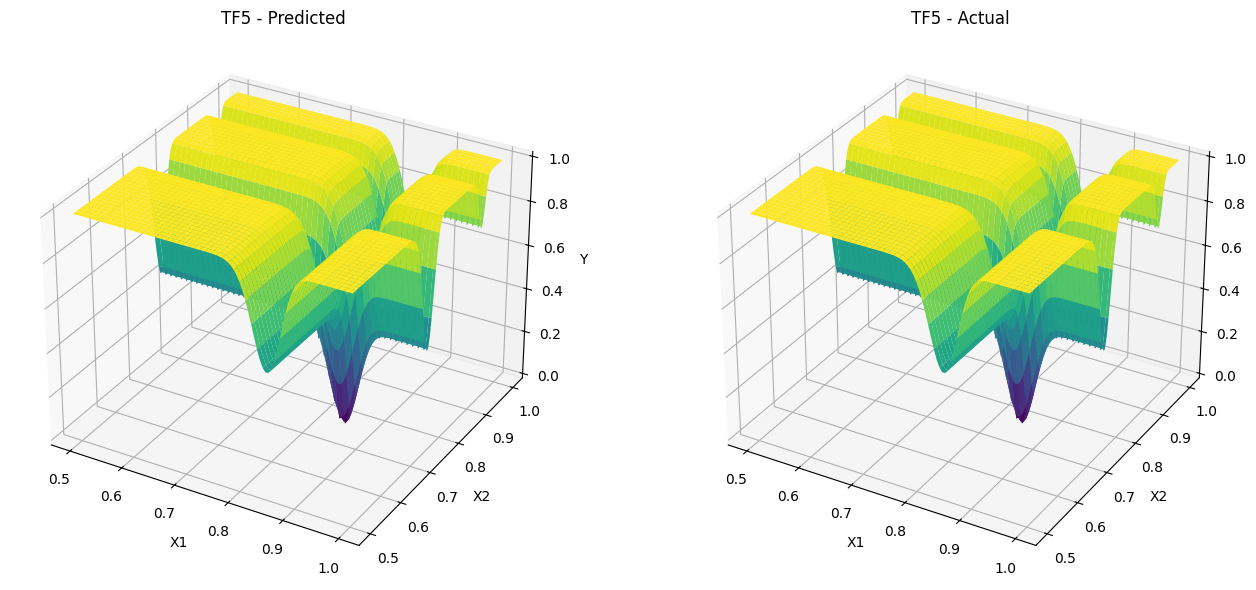

In [44]:
tf5_y_test_pred = predict_hkan(tf5_model, tf5_x_test)
plot_3d_surface("TF5", tf5_x_test[:, :2], tf5_y_test, tf5_y_test_pred)

### KAN

In [ ]:
# --- Study setup with K-Fold CV -----------------------------------------------
print("=" * 70)
print("Optimizing KAN architecture with 5-Fold Cross-Validation on TF5")
print("=" * 70)

study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.GridSampler(
        {"width_idx": list(range(10))}  # Exhaustive over all 10 architectures
    ),
)

n = tf5_x_train.shape[1]
width_options = [
    [n, 1], [n, 2, 1], [n, n+1, 1], [n, 2*n+1, 1], [n, 2, 2, 1],
    [n, n+1, 2, 1], [n, 2*n+1, 2, 1], [n, n+1, n+1, 1],
    [n, 2*n+1, n+1, 1], [n, 2*n+1, 2*n+1, 1],
]

study.optimize(
    lambda trial: objective_kan(
        trial, tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test, n_splits=5
    ),
    n_trials=10,
    show_progress_bar=True,
)

# --- Results ---------------------------------------------------------------
print("\n" + "=" * 70)
print("Best trial results:")
print("=" * 70)
print(f"Best CV Validation RMSE: {study.best_value:.6f}")
best_test_rmse = study.best_trial.user_attrs.get("test_rmse", "N/A")
print(f"Best Test RMSE:          {best_test_rmse:.6f}" if isinstance(best_test_rmse, float) else f"Best Test RMSE: {best_test_rmse}")
print(f"Best width_idx:          {study.best_params['width_idx']}")
print(f"Best architecture:       {width_options[study.best_params['width_idx']]}")

# Display all trials with both validation and test RMSE
trials_df = study.trials_dataframe()
print(f"\nAll {len(trials_df)} trials:")
print(trials_df[['number', 'value', 'params_width_idx', 'user_attrs_val_rmse', 'user_attrs_test_rmse']].to_string())

trials_df = trials_df.rename(columns={
    "user_attrs_test_rmse": "test_rmse",
    "user_attrs_val_rmse": "val_rmse",
})
trials_df['duration'] = trials_df['duration'].dt.total_seconds()
trials_df.to_csv("data/tf5_kan_optuna_search.csv")

In [ ]:
tf5_kan_optuna_search = pd.read_csv("data/tf5_kan_optuna_search.csv")
tf5_kan_optuna_search.sort_values("val_rmse")

### GP (Gaussian Process Baseline)

In [ ]:
# --- Study setup with K-Fold CV -----------------------------------------------
print("=" * 70)
print("Optimizing GP hyperparameters with 5-Fold Cross-Validation on TF5")
print("=" * 70)

study = optuna.create_study(direction='minimize')

study.optimize(
    lambda trial: objective_gp(trial, tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test, n_splits=5),
    n_trials=10,
    show_progress_bar=True,
)

# --- Results ---------------------------------------------------------------
print("\n" + "=" * 70)
print("Best trial results:")
print("=" * 70)
print(f"Best CV Validation RMSE: {study.best_value:.6f}")
best_test_rmse = study.best_trial.user_attrs.get("test_rmse", "N/A")
print(f"Best Test RMSE:          {best_test_rmse:.6f}" if isinstance(best_test_rmse, float) else f"Best Test RMSE: {best_test_rmse}")
print(f"Best hyperparameters:")
print(f"  lr:              {study.best_params['lr']:.6f}")
print(f"  kernel:          {study.best_params['kernel']}")
print(f"  num_inducing:    {study.best_params['num_inducing']}")

# Display all trials
trials_df = study.trials_dataframe()
print(f"\nAll {len(trials_df)} trials:")
print(trials_df[['number', 'value', 'params_lr', 'params_kernel', 'params_num_inducing', 'user_attrs_test_rmse']].to_string())

trials_df = trials_df.rename(columns={
    "user_attrs_test_rmse": "test_rmse",
    "user_attrs_val_rmse": "val_rmse",
})
trials_df['duration'] = trials_df['duration'].dt.total_seconds()
trials_df.to_csv("data/tf5_gp_optuna_search.csv")

In [ ]:
tf5_gp_optuna_search = pd.read_csv("data/tf5_gp_optuna_search.csv")
tf5_gp_optuna_search.sort_values("val_rmse")

### SGKAN

### SGKAN (Surrogate-Guided KAN) - Hyperparameter Optimization

In [ ]:
# --- Study setup with K-Fold CV -----------------------------------------------
print("=" * 70)
print("Optimizing SGKAN hyperparameters with 5-Fold Cross-Validation on TF5")
print("=" * 70)


study = optuna.create_study(direction='minimize')

study.optimize(
    lambda trial: objective_sgkan(
        trial, tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test,
        kernel=create_matern_kernel(tf5_x_train.shape[1]), lr=0.005705, num_inducing=331, num_iters=500,
        n_splits=5
    ),
    n_trials=10,
    show_progress_bar=True,
)

# --- Results ---------------------------------------------------------------
print("\n" + "=" * 70)
print("Best trial results:")
print("=" * 70)
print(f"Best CV Validation RMSE: {study.best_value:.6f}")
best_test_rmse = study.best_trial.user_attrs.get("test_rmse", "N/A")
print(f"Best Test RMSE:          {best_test_rmse:.6f}" if isinstance(best_test_rmse, float) else f"Best Test RMSE: {best_test_rmse}")
print(f"Best hyperparameters:")
print(f"  width:  {study.best_params['width']}")
print(f"  M:      {study.best_params['M']}")
print(f"  G:      {study.best_params['G']}")
print(f"  T:      {study.best_params['T']}")

# Display all trials
trials_df = study.trials_dataframe()
print(f"\nAll {len(trials_df)} trials:")
print(trials_df[['number', 'value', 'params_width', 'params_M', 'params_G', 'params_T', 'user_attrs_test_rmse']].to_string())

trials_df = trials_df.rename(columns={
    "user_attrs_test_rmse": "test_rmse",
    "user_attrs_val_rmse": "val_rmse",
})
trials_df['duration'] = trials_df['duration'].dt.total_seconds()
trials_df.to_csv("data/tf5_sgkan_optuna_search.csv")

In [ ]:
tf5_sgkan_optuna_search = pd.read_csv("data/tf5_sgkan_optuna_search.csv")
tf5_sgkan_optuna_search.sort_values("val_rmse")